# IS2SITMOGR4-V4 and IS2SMGPSIT-V1 vs BGEP ULS ice draft (daily / weekly)

**Summary**: Compares BGEP ULS draft with IS2SITMOGR4-V4 (nearest monthly) and IS2SMGPSIT-V1 (monthly-resampled, daily, and weekly means) at moorings A, B, and D. Extends notebook 11b to sub-monthly timescales, includes the 1–30 day anomaly-window sweep, and writes the combined daily/weekly/monthly validation table used in the manuscript (`tab:windows`).

**Author**: Alek Petty  
**Version history**: Version 1 (08/2026)


# Import notebook dependencies

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import pyproj
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl

from utils.read_data_utils import read_IS2SITMOGR4, read_is2smgpsitv1_zarr

%config InlineBackend.figure_format = 'retina'
mpl.rcParams['figure.dpi'] = 300

import warnings
warnings.filterwarnings('ignore')

In [2]:
mpl.rcParams.update({
    'text.usetex': False,
    'font.family': 'sans-serif',
    'mathtext.fontset': 'stixsans',
    'lines.linewidth': 1.,
    'font.size': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7
})
mpl.rcParams['font.sans-serif'] = ['Arial']

## Load products

Load IS2SITMOGR4-V4 (monthly), IS2SMGPSIT-V1 (daily and monthly resampled).

In [3]:
int_str = '_int'

# --- IS2SITMOGR4-V4 monthly --- (small: 54 months, persist in memory)
IS2_v4 = read_IS2SITMOGR4(data_type='zarr-s3-v4', persist=True)
_v4_time = pd.to_datetime(IS2_v4['time'].values)
_v4_start = _v4_time.to_period('M').to_timestamp(how='start')
_v4_mid = _v4_start + pd.Timedelta(days=14)
IS2_v4 = IS2_v4.assign_coords(time=_v4_mid.values)
print('IS2SITMOGR4-V4 monthly loaded:', len(IS2_v4.time), 'months')

# --- IS2SMGPSIT-V1 daily --- (large: 1625 days, keep lazy — bounding-box isel limits S3 reads)
IS2_SMOS_SMAP = read_is2smgpsitv1_zarr(persist=False, load_cache=True)
print('IS2SMGPSIT-V1 daily loaded:', len(IS2_SMOS_SMAP.time), 'days')

# --- IS2SMGPSIT-V1 monthly (resample daily -> monthly mean, mid-month timestamps) ---
IS2_SMOS_SMAP_monthly = IS2_SMOS_SMAP.sortby('time').resample(time='1ME').mean()
_fused_time = pd.to_datetime(IS2_SMOS_SMAP_monthly['time'].values)
_fused_start = _fused_time.to_period('M').to_timestamp(how='start')
_fused_mid = _fused_start + pd.Timedelta(days=14)
IS2_SMOS_SMAP_monthly = IS2_SMOS_SMAP_monthly.assign_coords(time=_fused_mid.values)

if 'latitude' in IS2_SMOS_SMAP.coords:
    IS2_SMOS_SMAP_monthly = IS2_SMOS_SMAP_monthly.assign_coords(latitude=IS2_SMOS_SMAP['latitude'])
if 'longitude' in IS2_SMOS_SMAP.coords:
    IS2_SMOS_SMAP_monthly = IS2_SMOS_SMAP_monthly.assign_coords(longitude=IS2_SMOS_SMAP['longitude'])

print('IS2SMGPSIT-V1 monthly loaded:', len(IS2_SMOS_SMAP_monthly.time), 'months')

load zarr from S3 bucket
zarr_path: s3://icesat-2-sea-ice-us-west-2/IS2SITMOGR4_V4/zarr/IS2SITMOGR4_V4_201811-202504.zarr
IS2SITMOGR4-V4 monthly loaded: 54 months
Loading IS2-SMOS-SMAP (is2smsitgp) Zarr from local cache
cache_path: ./data/cache/GPSat_multivar_20181101-20250430.zarr
IS2SMGPSIT-V1 daily loaded: 1635 days
IS2SMGPSIT-V1 monthly loaded: 78 months


## Map projection and grid setup

Moorings (lon/lat) projected to EPSG:3411. Meshgrids from each dataset's `x`/`y` coordinates enable distance-based collocation.

In [4]:
out_proj = 'EPSG:3411'
mapProj = pyproj.Proj('+init=' + out_proj)

# Mooring lon/lat -> map x/y (metres) via get_uls_year; meshgrids for collocation are built
# after ice draft is computed (next section) so xpts_* / ypts_* stay with the gridded products.

## Compute ice draft from IS2 thickness

Ice draft = thickness – freeboard + snow_depth

In [5]:
# IS2SITMOGR4-V4 monthly ice draft
IS2_v4['ice_draft_v4'] = (
    IS2_v4['ice_thickness' + int_str]
    - IS2_v4['freeboard' + int_str]
    + IS2_v4['snow_depth' + int_str]
)

# IS2SMGPSIT-V1 monthly ice draft
IS2_SMOS_SMAP_monthly['ice_draft_fused'] = (
    IS2_SMOS_SMAP_monthly['ice_thickness']
    - IS2_SMOS_SMAP_monthly['freeboard']
    + IS2_SMOS_SMAP_monthly['snow_depth']
)

# IS2SMGPSIT-V1 daily ice draft
IS2_SMOS_SMAP['ice_draft_fused_daily'] = (
    IS2_SMOS_SMAP['ice_thickness']
    - IS2_SMOS_SMAP['freeboard']
    + IS2_SMOS_SMAP['snow_depth']
)



# Grid node locations (EPSG:3411 m) for distance to moorings in grid_IS2_nearby
xpts_v4, ypts_v4 = np.meshgrid(IS2_v4.x.values, IS2_v4.y.values)
xpts_fused, ypts_fused = np.meshgrid(IS2_SMOS_SMAP.x.values, IS2_SMOS_SMAP.y.values)
xpts_fused_monthly, ypts_fused_monthly = np.meshgrid(
    IS2_SMOS_SMAP_monthly.x.values, IS2_SMOS_SMAP_monthly.y.values
)

print('Ice draft variables computed for IS2SITMOGR4-V4 monthly, IS2SMGPSIT-V1 monthly, and IS2SMGPSIT-V1 daily')
print('Meshgrids ready: V4', xpts_v4.shape, 'fused daily', xpts_fused.shape, 'fused monthly', xpts_fused_monthly.shape)

Ice draft variables computed for IS2SITMOGR4-V4 monthly, IS2SMGPSIT-V1 monthly, and IS2SMGPSIT-V1 daily
Meshgrids ready: V4 (448, 304) fused daily (448, 304) fused monthly (448, 304)


## Wrangle BGEP ULS draft data (moorings A, B, D)

Use the same `uls{YY}{a|b|d}_draft.dat` files in `./data/` as notebook 11b (YY = 18, 21, 22, **23**).


In [6]:
dataPathULS = './data/'

def get_uls_year(letter, year):
    if letter == 'a':
        print('Mooring A (75.0 N, 150 W)')
        uls_x, uls_y = mapProj(-150., 75.)
    if letter == 'b':
        print('Mooring B (78.4 N, 150.0 W)')
        uls_x, uls_y = mapProj(-150., 78.4)
    if letter == 'd':
        print('Mooring D (74.0 N, 140.0 W)')
        uls_x, uls_y = mapProj(-140., 74.)

    uls = pd.read_csv(
        dataPathULS + 'uls' + year + letter + '_draft.dat',
        sep='\s+', names=['date', 'time', 'draft'], header=2,
    )
    utc_datetime_uls = pd.to_datetime(uls['date'], format='%Y%m%d')

    uls_mean_daily_draft = uls['draft'].groupby([utc_datetime_uls.dt.date]).mean()
    uls_mean_monthly_draft = uls['draft'].groupby([utc_datetime_uls.dt.to_period('M')]).mean()

    return uls_mean_daily_draft, uls_mean_monthly_draft, uls_x, uls_y

In [7]:
uls_mean_daily_draft_a_18, uls_mean_monthly_draft_a_18, uls_x_a, uls_y_a = get_uls_year('a', '18')
uls_mean_daily_draft_b_18, uls_mean_monthly_draft_b_18, uls_x_b, uls_y_b = get_uls_year('b', '18')
uls_mean_daily_draft_d_18, uls_mean_monthly_draft_d_18, uls_x_d, uls_y_d = get_uls_year('d', '18')

uls_mean_daily_draft_a_21, uls_mean_monthly_draft_a_21, _, _ = get_uls_year('a', '21')
uls_mean_daily_draft_b_21, uls_mean_monthly_draft_b_21, _, _ = get_uls_year('b', '21')
uls_mean_daily_draft_d_21, uls_mean_monthly_draft_d_21, _, _ = get_uls_year('d', '21')

uls_mean_daily_draft_a_22, uls_mean_monthly_draft_a_22, _, _ = get_uls_year('a', '22')
uls_mean_daily_draft_b_22, uls_mean_monthly_draft_b_22, _, _ = get_uls_year('b', '22')
uls_mean_daily_draft_d_22, uls_mean_monthly_draft_d_22, _, _ = get_uls_year('d', '22')

uls_mean_daily_draft_a_23, uls_mean_monthly_draft_a_23, _, _ = get_uls_year('a', '23')
uls_mean_daily_draft_b_23, uls_mean_monthly_draft_b_23, _, _ = get_uls_year('b', '23')
uls_mean_daily_draft_d_23, uls_mean_monthly_draft_d_23, _, _ = get_uls_year('d', '23')

Mooring A (75.0 N, 150 W)
Mooring B (78.4 N, 150.0 W)
Mooring D (74.0 N, 140.0 W)
Mooring A (75.0 N, 150 W)
Mooring B (78.4 N, 150.0 W)
Mooring D (74.0 N, 140.0 W)
Mooring A (75.0 N, 150 W)
Mooring B (78.4 N, 150.0 W)
Mooring D (74.0 N, 140.0 W)
Mooring A (75.0 N, 150 W)
Mooring B (78.4 N, 150.0 W)
Mooring D (74.0 N, 140.0 W)


In [8]:
uls_daily = {
    'a': pd.concat([uls_mean_daily_draft_a_18, uls_mean_daily_draft_a_21, uls_mean_daily_draft_a_22, uls_mean_daily_draft_a_23]),
    'b': pd.concat([uls_mean_daily_draft_b_18, uls_mean_daily_draft_b_21, uls_mean_daily_draft_b_22, uls_mean_daily_draft_b_23]),
    'd': pd.concat([uls_mean_daily_draft_d_18, uls_mean_daily_draft_d_21, uls_mean_daily_draft_d_22, uls_mean_daily_draft_d_23]),
}

mooring_xy = {
    'a': (uls_x_a, uls_y_a),
    'b': (uls_x_b, uls_y_b),
    'd': (uls_x_d, uls_y_d),
}

for letter in ['a', 'b', 'd']:
    print(f'Mooring {letter.upper()}: {len(uls_daily[letter])} daily ULS values')

Mooring A: 2124 daily ULS values
Mooring B: 2038 daily ULS values
Mooring D: 2167 daily ULS values


## Collocate IS2 with daily ULS

For each ULS date: nearest IS2 field (V4/fused-monthly within 20 days; fused-daily exact match) averaged within 100 km of each mooring.

In [9]:
comp_res = 100000

def grid_IS2_nearby(ds, var_name, date, uls_x, uls_y, xpts, ypts, res=100000,
                    method='nearest', tolerance=pd.Timedelta(days=20)):
    """Average IS2 grid cells within `res` metres of a mooring for a given date."""
    try:
        IS2 = ds[var_name].sel(time=date, method=method, tolerance=tolerance)
    except KeyError:
        return np.nan
    dist = np.sqrt((xpts - uls_x)**2 + (ypts - uls_y)**2)
    IS2_uls = IS2.where(dist < res).mean()
    return float(IS2_uls.values)

In [10]:
# OPTIMISED VERSION — spatial bounding box + single compute per product per mooring
# Key fix: isel to a tight ~8x8 cell bounding box around the mooring *before* any
# Dask computation, so only ~64 cells (not 136k) are pulled from S3 per product.

def spatial_ts_fast(ds, var, xpts, ypts, uls_x, uls_y, res=comp_res):
    """Full time series of spatial mean, loading only the bounding box from S3."""
    dist = np.sqrt((xpts - uls_x)**2 + (ypts - uls_y)**2)
    mask2d = dist < res
    rows, cols = np.where(mask2d)
    y_sl = slice(int(rows.min()), int(rows.max()) + 1)
    x_sl = slice(int(cols.min()), int(cols.max()) + 1)
    local_mask = mask2d[y_sl, x_sl]

    # Load only this small region for all time steps in one shot
    sub = ds[var].isel(y=y_sl, x=x_sl)
    ts = sub.where(local_mask).mean(dim=['y', 'x']).compute().to_series()
    ts.index = pd.to_datetime(ts.index)
    return ts.sort_index()

colloc = {}
tol = pd.Timedelta(days=20)

for letter in ['a', 'b', 'd']:
    uls_x, uls_y = mooring_xy[letter]
    daily_series = uls_daily[letter]
    dates = pd.to_datetime(daily_series.index)

    v4_ts      = spatial_ts_fast(IS2_v4,                'ice_draft_v4',          xpts_v4,            ypts_v4,            uls_x, uls_y)
    fused_m_ts = spatial_ts_fast(IS2_SMOS_SMAP_monthly, 'ice_draft_fused',       xpts_fused_monthly, ypts_fused_monthly, uls_x, uls_y)
    fused_d_ts = spatial_ts_fast(IS2_SMOS_SMAP,         'ice_draft_fused_daily', xpts_fused,         ypts_fused,         uls_x, uls_y)

    uls_df = pd.DataFrame({'uls_draft': daily_series.values}, index=dates).sort_index()

    df = uls_df.copy()
    df['v4_monthly']    = pd.merge_asof(uls_df, v4_ts.rename('v'),      left_index=True, right_index=True, tolerance=tol, direction='nearest')['v']
    df['fused_monthly'] = pd.merge_asof(uls_df, fused_m_ts.rename('v'), left_index=True, right_index=True, tolerance=tol, direction='nearest')['v']
    df['fused_daily']   = fused_d_ts.reindex(dates)

    colloc[letter] = df
    print(f'Mooring {letter.upper()}: {len(df)} days, '
          f'V4 valid={df["v4_monthly"].notna().sum()}, '
          f'fused-monthly valid={df["fused_monthly"].notna().sum()}, '
          f'fused-daily valid={df["fused_daily"].notna().sum()}')

Mooring A: 2124 days, V4 valid=1251, fused-monthly valid=1372, fused-daily valid=1360
Mooring B: 2038 days, V4 valid=1413, fused-monthly valid=1399, fused-daily valid=1387
Mooring D: 2167 days, V4 valid=1327, fused-monthly valid=1405, fused-daily valid=1394


In [11]:
""" colloc = {}  # letter -> DataFrame

# Fused daily: only use days that exist in the product (no nearest-neighbour interpolation)
fused_time_arr = pd.to_datetime(IS2_SMOS_SMAP.time.values)

for letter in ['a', 'b', 'd']:
    uls_x, uls_y = mooring_xy[letter]
    daily_series = uls_daily[letter]
    dates = pd.to_datetime(daily_series.index)

    v4_vals = []
    fused_monthly_vals = []
    fused_daily_vals = []

    for d in dates:
        v4_vals.append(
            grid_IS2_nearby(IS2_v4, 'ice_draft_v4', d, uls_x, uls_y,
                            xpts_v4, ypts_v4,
                            res=comp_res, tolerance=pd.Timedelta(days=20))
        )
        fused_monthly_vals.append(
            grid_IS2_nearby(IS2_SMOS_SMAP_monthly, 'ice_draft_fused', d, uls_x, uls_y,
                            xpts_fused_monthly, ypts_fused_monthly,
                            res=comp_res, tolerance=pd.Timedelta(days=20))
        )
        # Daily: only plot days that exist in the fused product (exact date match)
        same_day = np.array([t.date() == d.date() for t in fused_time_arr])
        if np.any(same_day):
            t_exact = IS2_SMOS_SMAP.time.values[np.argmax(same_day)]
            fused_daily_vals.append(
                grid_IS2_nearby(IS2_SMOS_SMAP, 'ice_draft_fused_daily', t_exact, uls_x, uls_y,
                                xpts_fused, ypts_fused,
                                res=comp_res, method='nearest', tolerance=pd.Timedelta(0))
            )
        else:
            fused_daily_vals.append(np.nan)

    df = pd.DataFrame({
        'uls_draft': daily_series.values,
        'v4_monthly': v4_vals,
        'fused_monthly': fused_monthly_vals,
        'fused_daily': fused_daily_vals,
    }, index=dates)
    colloc[letter] = df
    print(f'Mooring {letter.upper()}: {len(df)} days, '
          f'V4 valid={df["v4_monthly"].notna().sum()}, '
          f'fused-monthly valid={df["fused_monthly"].notna().sum()}, '
          f'fused-daily valid={df["fused_daily"].notna().sum()}') """

' colloc = {}  # letter -> DataFrame\n\n# Fused daily: only use days that exist in the product (no nearest-neighbour interpolation)\nfused_time_arr = pd.to_datetime(IS2_SMOS_SMAP.time.values)\n\nfor letter in [\'a\', \'b\', \'d\']:\n    uls_x, uls_y = mooring_xy[letter]\n    daily_series = uls_daily[letter]\n    dates = pd.to_datetime(daily_series.index)\n\n    v4_vals = []\n    fused_monthly_vals = []\n    fused_daily_vals = []\n\n    for d in dates:\n        v4_vals.append(\n            grid_IS2_nearby(IS2_v4, \'ice_draft_v4\', d, uls_x, uls_y,\n                            xpts_v4, ypts_v4,\n                            res=comp_res, tolerance=pd.Timedelta(days=20))\n        )\n        fused_monthly_vals.append(\n            grid_IS2_nearby(IS2_SMOS_SMAP_monthly, \'ice_draft_fused\', d, uls_x, uls_y,\n                            xpts_fused_monthly, ypts_fused_monthly,\n                            res=comp_res, tolerance=pd.Timedelta(days=20))\n        )\n        # Daily: only plot day

## Validation statistics

**r²**: coefficient of determination. **MB**: mean bias (IS2 − ULS). **SD**: standard deviation of differences. **RMSE**: root-mean-square error. Stats computed per mooring (A, B, D) and pooled (ALL).

In [12]:
products = ['v4_monthly', 'fused_monthly', 'fused_daily']
product_labels = ['IS2SITMOGR4-V4 (monthly)', 'IS2SMGPSIT-V1 (monthly)', 'IS2SMGPSIT-V1 (daily)']

validation_results = {}

for prod, label in zip(products, product_labels):
    vr = {}
    for letter in ['a', 'b', 'd']:
        df = colloc[letter]
        mask = np.isfinite(df['uls_draft']) & np.isfinite(df[prod])
        if mask.sum() >= 2:
            res = stats.linregress(df[prod][mask], df['uls_draft'][mask])
            vr[f'r2_{letter}'] = res.rvalue**2
            vr[f'mb_{letter}'] = np.nanmean(df[prod][mask].values - df['uls_draft'][mask].values)
            vr[f'sd_{letter}'] = np.nanstd(df[prod][mask].values - df['uls_draft'][mask].values)
            vr[f'rmse_{letter}'] = np.sqrt(np.nanmean((df[prod][mask].values - df['uls_draft'][mask].values)**2))
            vr[f'n_{letter}'] = int(mask.sum())
        else:
            vr[f'r2_{letter}'] = vr[f'mb_{letter}'] = vr[f'sd_{letter}'] = vr[f'rmse_{letter}'] = np.nan
            vr[f'n_{letter}'] = 0

    # Combined across all moorings
    all_is2 = np.concatenate([colloc[l][prod].values for l in ['a', 'b', 'd']])
    all_uls = np.concatenate([colloc[l]['uls_draft'].values for l in ['a', 'b', 'd']])
    mask_all = np.isfinite(all_is2) & np.isfinite(all_uls)
    if mask_all.sum() >= 2:
        res = stats.linregress(all_is2[mask_all], all_uls[mask_all])
        vr['r2_all'] = res.rvalue**2
        vr['mb_all'] = np.nanmean(all_is2[mask_all] - all_uls[mask_all])
        vr['sd_all'] = np.nanstd(all_is2[mask_all] - all_uls[mask_all])
        vr['rmse_all'] = np.sqrt(np.nanmean((all_is2[mask_all] - all_uls[mask_all])**2))
        vr['n_all'] = int(mask_all.sum())
    else:
        vr['r2_all'] = vr['mb_all'] = vr['sd_all'] = vr['rmse_all'] = np.nan
        vr['n_all'] = 0

    validation_results[prod] = vr

for prod, label in zip(products, product_labels):
    vr = validation_results[prod]
    print(f'\n{label}:')
    for letter in ['a', 'b', 'd', 'all']:
        print(f"  {letter.upper():>3s} (N={vr[f'n_{letter}']:4d}): "
              f"r\u00b2={vr[f'r2_{letter}']:.2f}  "
              f"MB={vr[f'mb_{letter}']:.2f} m  "
              f"SD={vr[f'sd_{letter}']:.2f} m  "
              f"RMSE={vr[f'rmse_{letter}']:.2f} m")


IS2SITMOGR4-V4 (monthly):
    A (N=1241): r²=0.70  MB=0.14 m  SD=0.32 m  RMSE=0.35 m
    B (N=1409): r²=0.75  MB=-0.02 m  SD=0.31 m  RMSE=0.31 m
    D (N=1326): r²=0.61  MB=0.20 m  SD=0.39 m  RMSE=0.44 m
  ALL (N=3976): r²=0.66  MB=0.11 m  SD=0.36 m  RMSE=0.37 m

IS2SMGPSIT-V1 (monthly):
    A (N=1361): r²=0.80  MB=0.04 m  SD=0.29 m  RMSE=0.30 m
    B (N=1395): r²=0.82  MB=-0.08 m  SD=0.27 m  RMSE=0.28 m
    D (N=1404): r²=0.69  MB=0.08 m  SD=0.38 m  RMSE=0.39 m
  ALL (N=4160): r²=0.75  MB=0.01 m  SD=0.33 m  RMSE=0.33 m

IS2SMGPSIT-V1 (daily):
    A (N=1349): r²=0.81  MB=0.03 m  SD=0.29 m  RMSE=0.29 m
    B (N=1383): r²=0.82  MB=-0.08 m  SD=0.27 m  RMSE=0.28 m
    D (N=1393): r²=0.69  MB=0.08 m  SD=0.39 m  RMSE=0.39 m
  ALL (N=4125): r²=0.76  MB=0.01 m  SD=0.33 m  RMSE=0.33 m


## Time series: daily ULS draft vs IS2 products at moorings A, B, D

IS2SMGPSIT-V1 daily uses exact date match only (no interpolation); gaps indicate days with no fused product data. A 7-day rolling mean is overlaid.

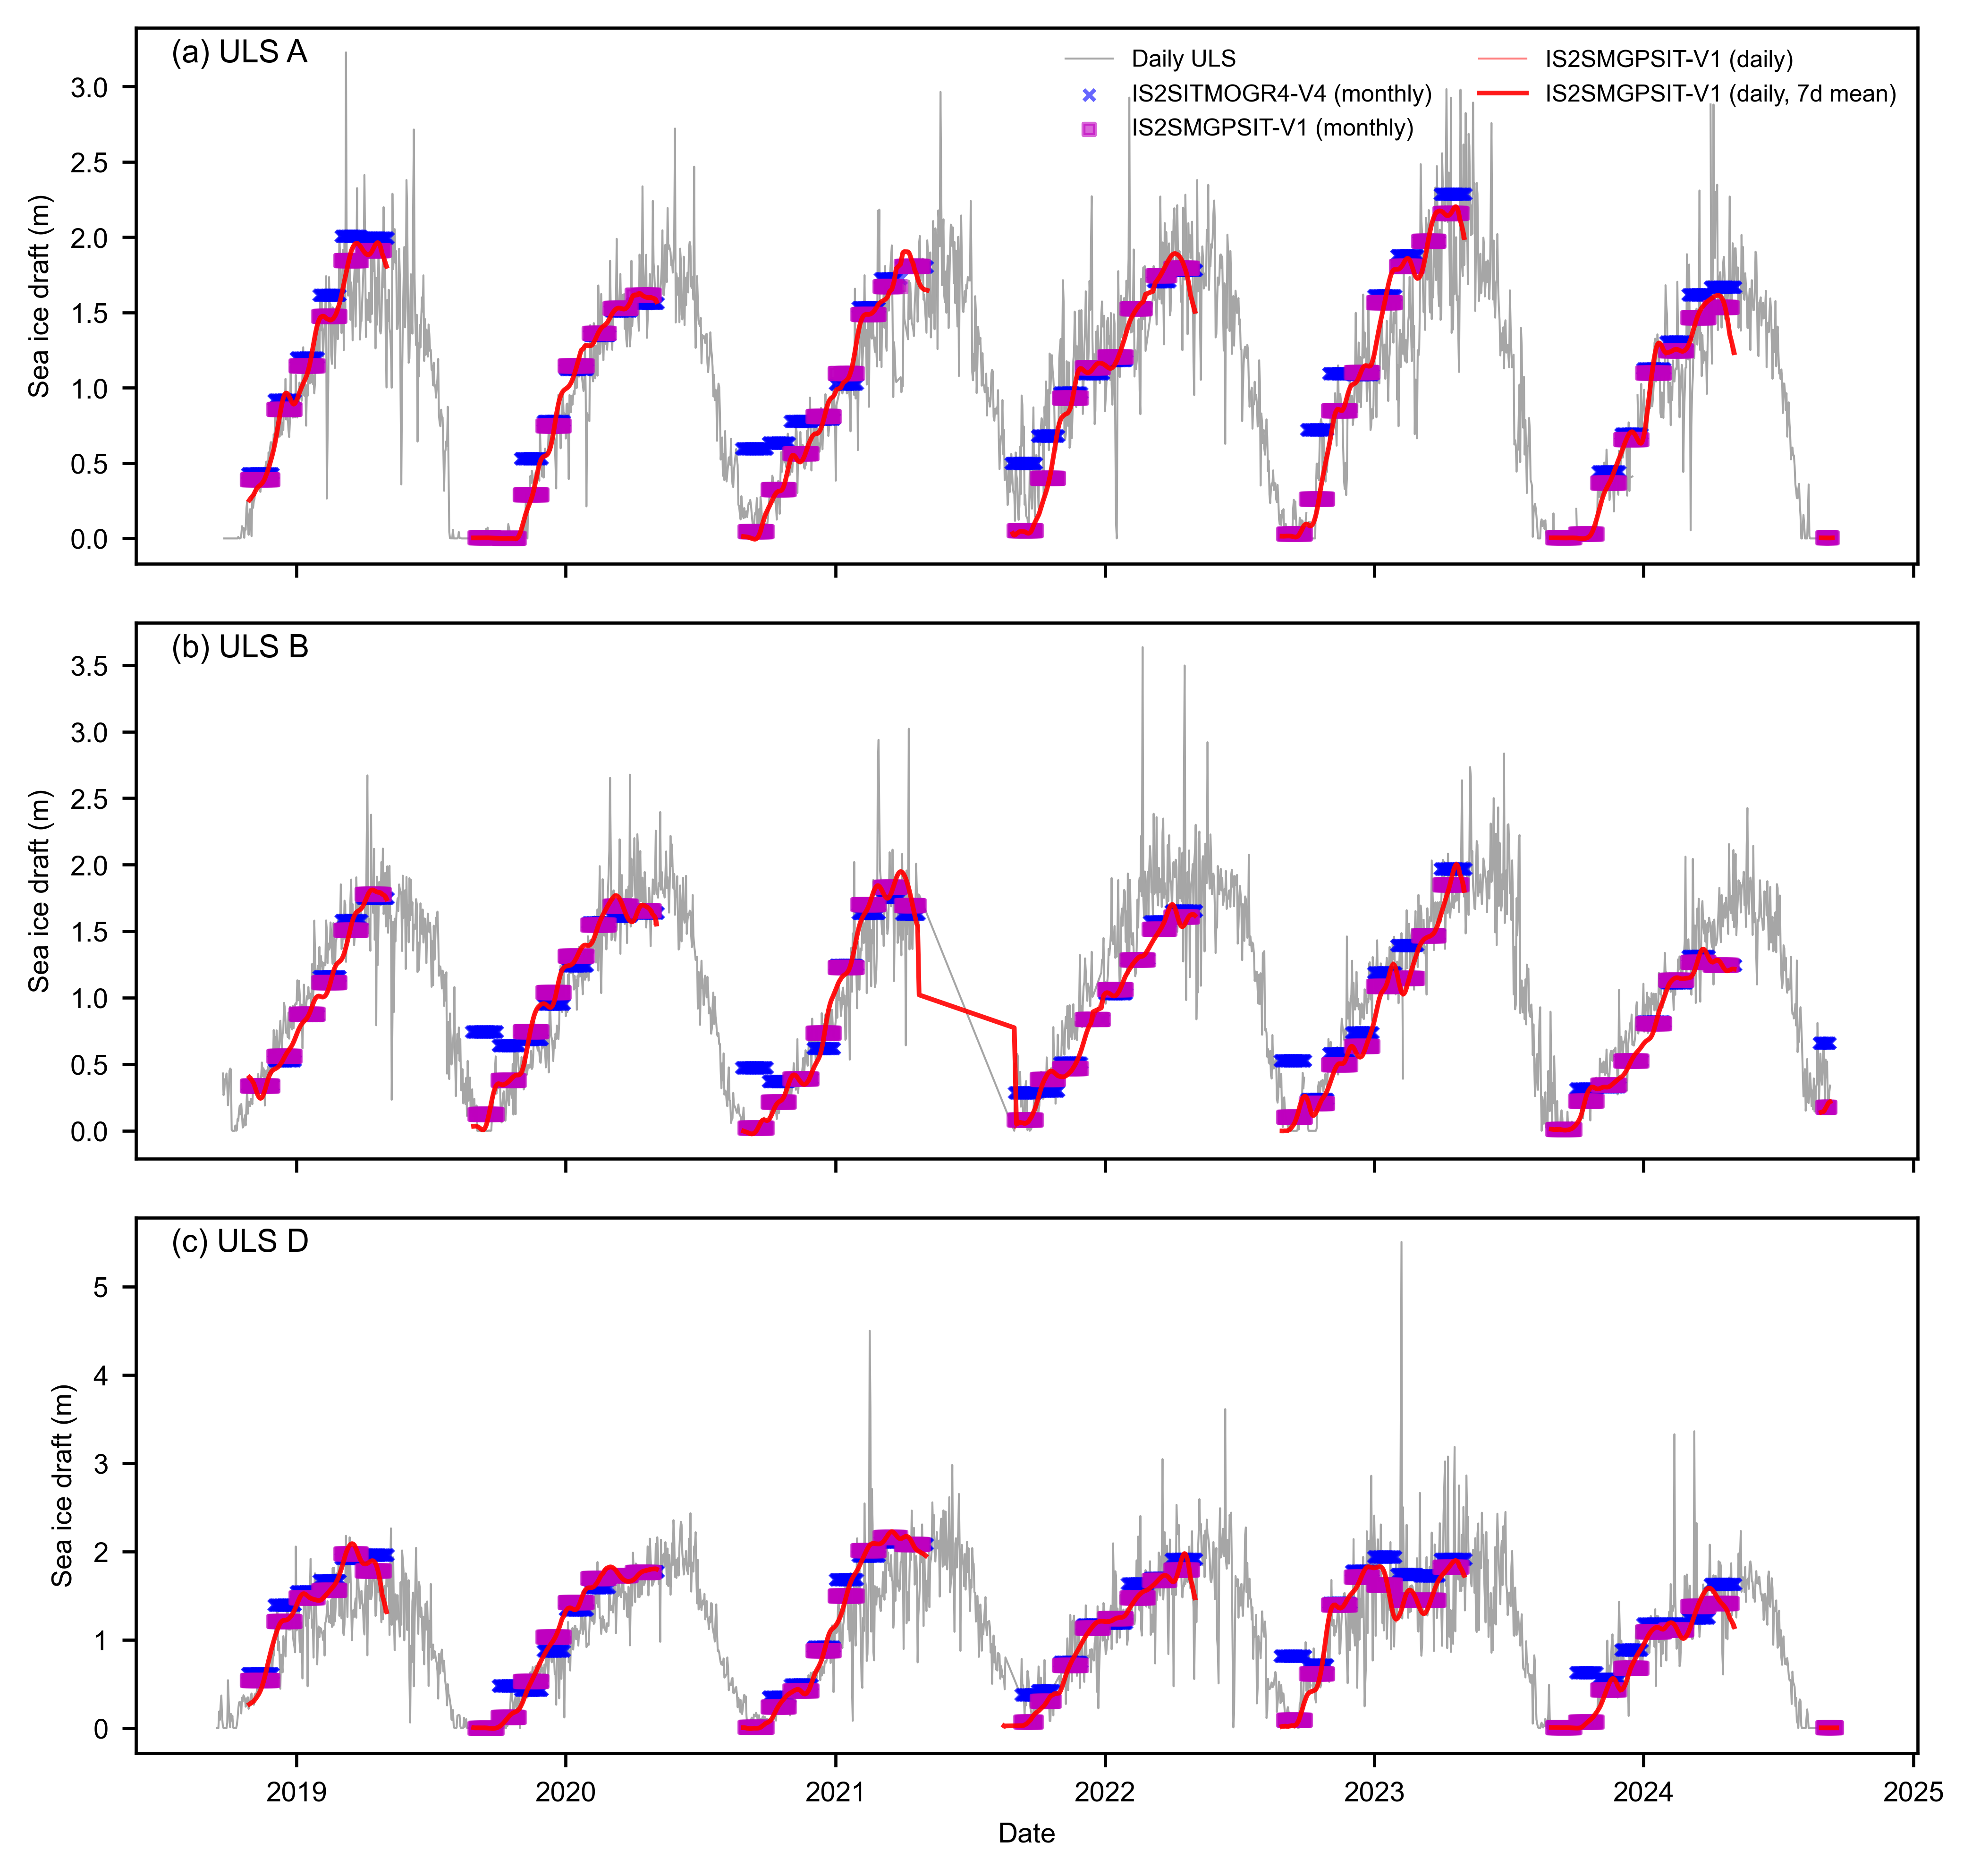

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(6.8, 7), sharex=True)

letters_plot = ['a', 'b', 'd']
panel_labels = ['(a) ULS A', '(b) ULS B', '(c) ULS D']

for ax, letter, panel_label in zip(axes, letters_plot, panel_labels):
    df = colloc[letter]

    # Daily ULS as grey background
    ax.plot(df.index, df['uls_draft'],
            color='gray', linewidth=0.5, alpha=0.7, label='Daily ULS')

    # IS2SITMOGR4-V4 monthly (nearest) -- plot only where valid
    mask_v4 = df['v4_monthly'].notna()
    ax.scatter(df.index[mask_v4], df['v4_monthly'][mask_v4],
               color='b', marker='x', s=8, alpha=0.6, label='IS2SITMOGR4-V4 (monthly)', zorder=4)

    # IS2SMGPSIT-V1 monthly (nearest)
    mask_fm = df['fused_monthly'].notna()
    ax.scatter(df.index[mask_fm], df['fused_monthly'][mask_fm],
               color='m', marker='s', s=8, alpha=0.6, label='IS2SMGPSIT-V1 (monthly)', zorder=4)

    # IS2SMGPSIT-V1 daily + 7-day rolling mean
    # Plot full series (with NaNs) so matplotlib breaks the line across May-Aug gaps
    ax.plot(df.index, df['fused_daily'],
            color='r', linewidth=0.5, alpha=0.5, label='IS2SMGPSIT-V1 (daily)', zorder=4)
    fused_daily_smooth = df['fused_daily'].rolling(7, center=True, min_periods=1).mean()
    ax.plot(df.index, fused_daily_smooth,
            color='r', linewidth=1.2, alpha=0.9, label='IS2SMGPSIT-V1 (daily, 7d mean)', zorder=5)

    ax.annotate(panel_label, xy=(0.02, 0.98), xycoords='axes fraction',
                verticalalignment='top')
    ax.set_ylabel('Sea ice draft (m)')

axes[0].legend(loc='upper right', frameon=False, ncol=2, fontsize=6)
axes[2].set_xlabel('Date')

plt.subplots_adjust(left=0.065, right=0.99, top=0.95, bottom=0.08, hspace=0.11)
plt.savefig('./figs/BGEP_V4_fused_daily_timeseries.png', dpi=300)
plt.show()

## Sub-seasonal variability

Remove day-of-year climatology to isolate weekly–monthly variability without the seasonal growth/melt signal.

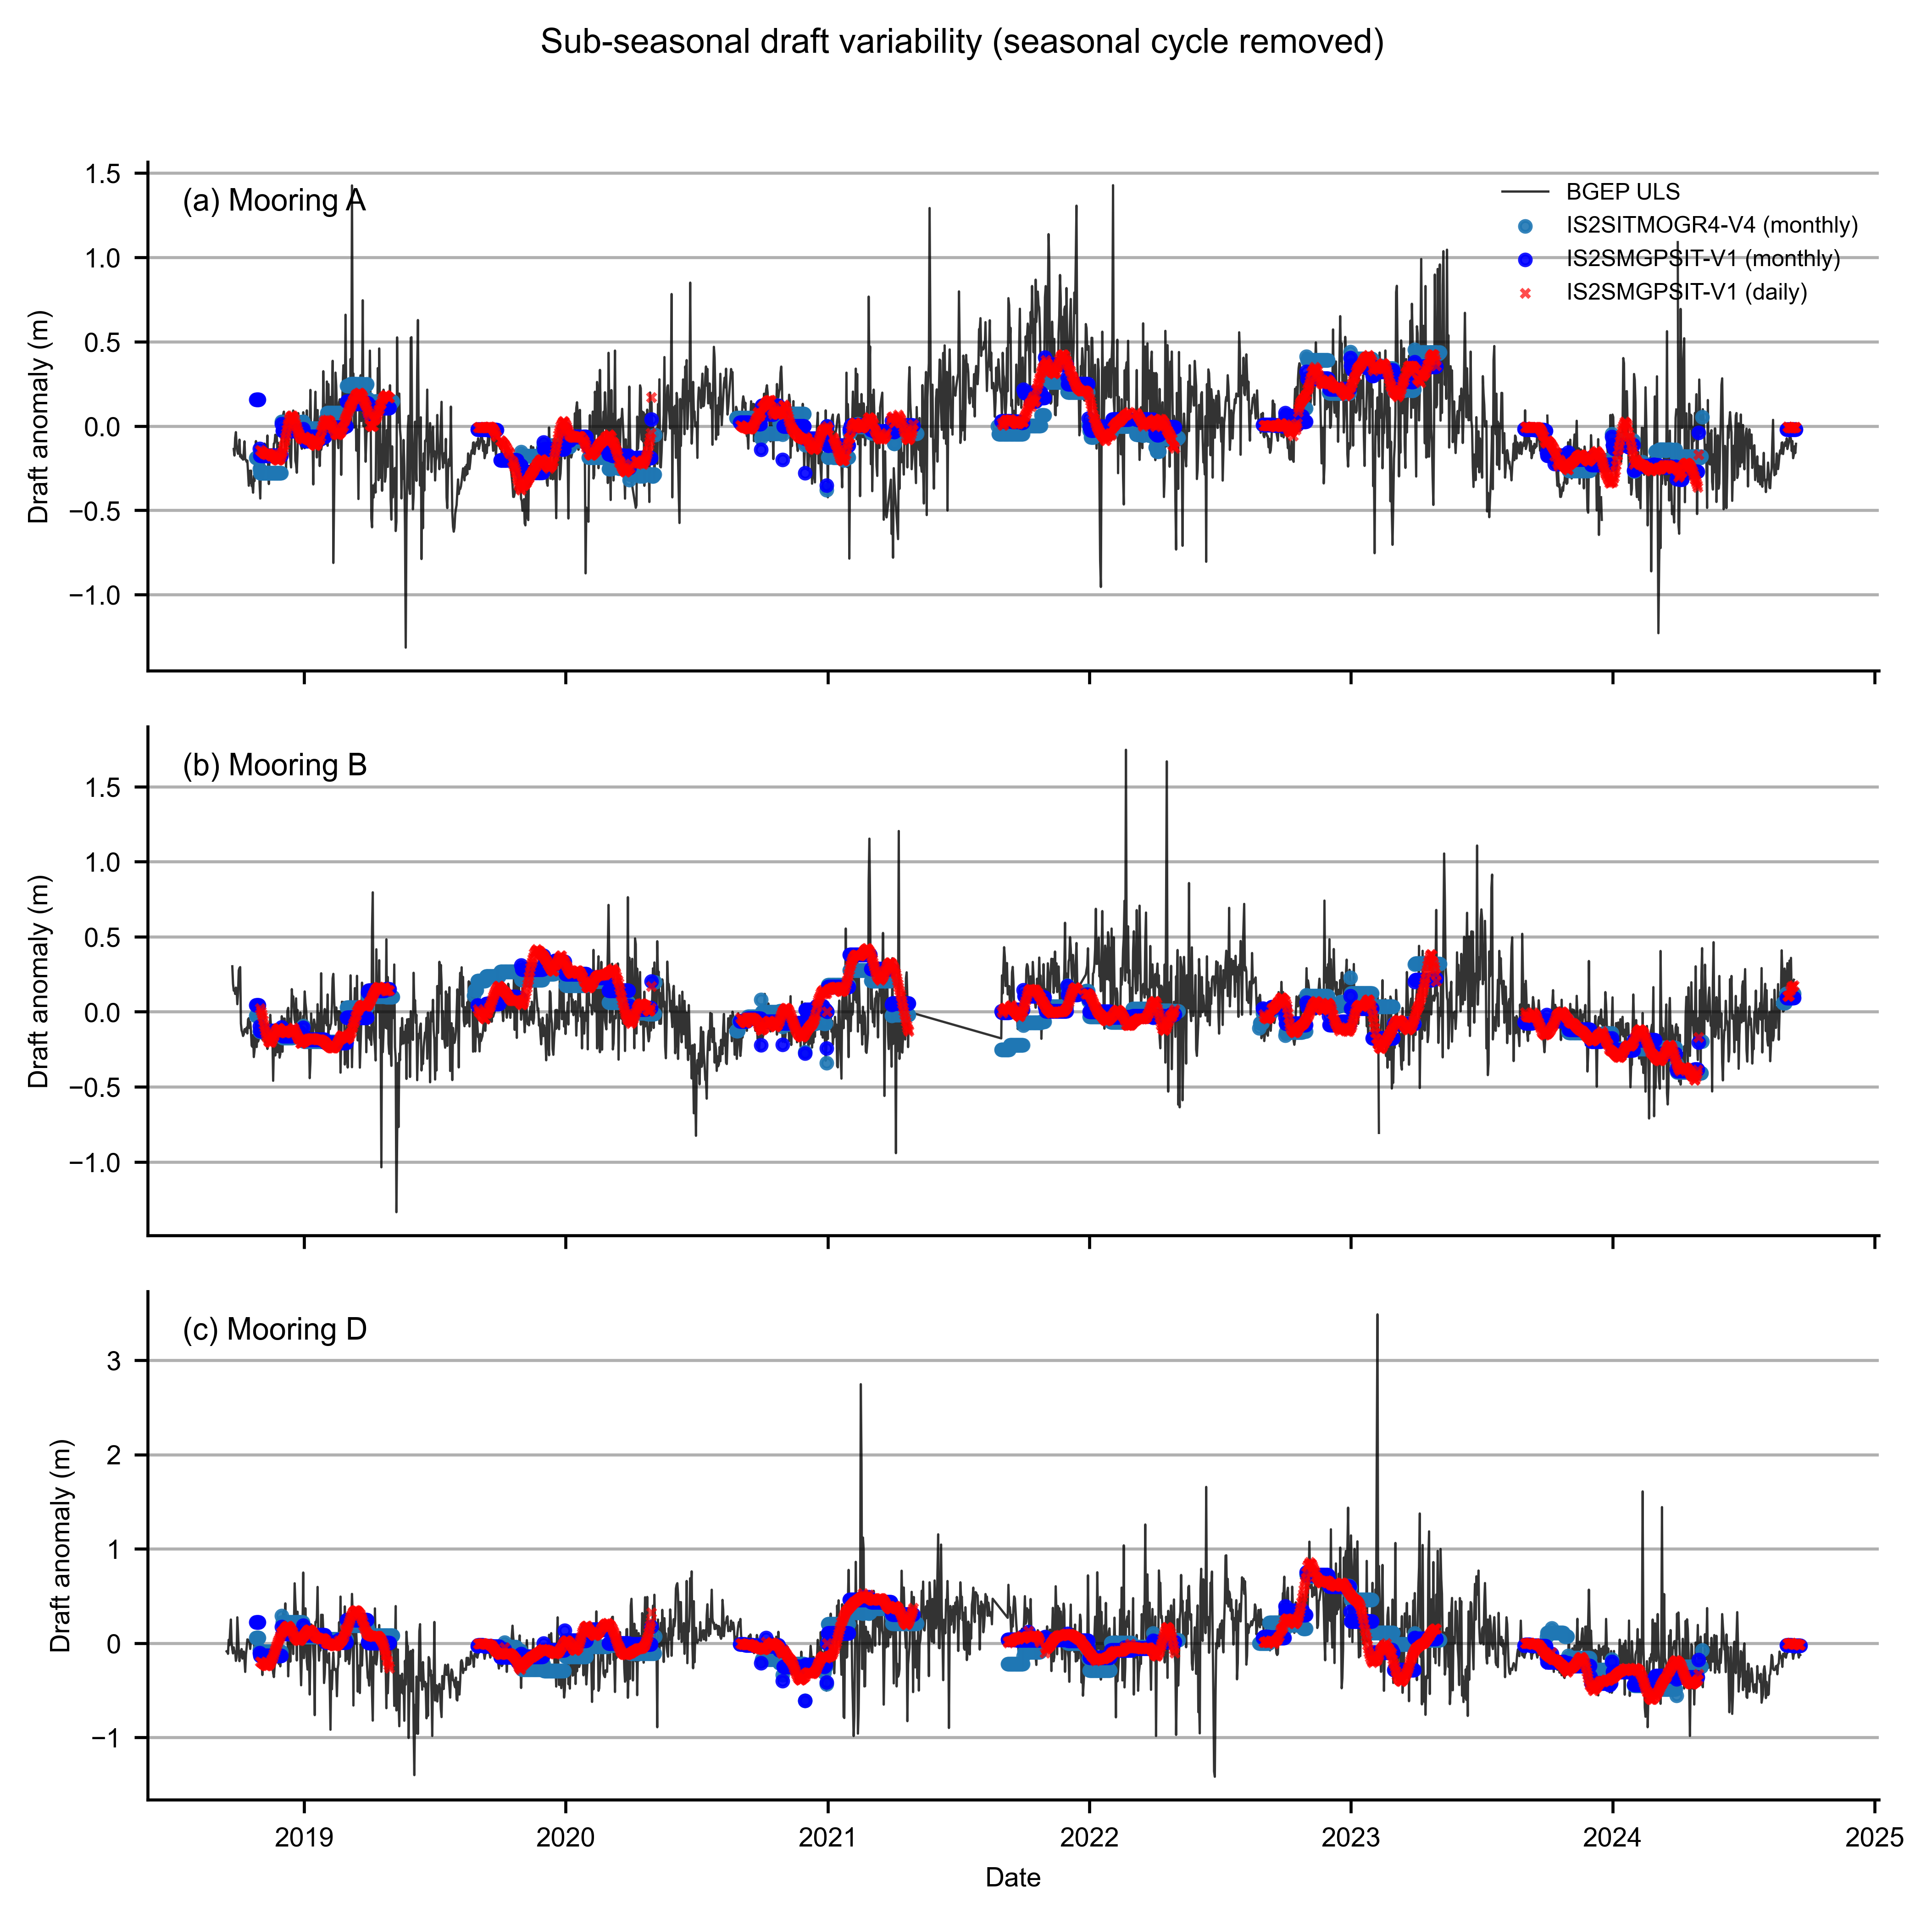

Correlation of BGEP ULS draft anomalies with IS2 products (pooled A+B+D):
  IS2SITMOGR4-V4 (monthly): r = 0.352, p = 4.90e-116, n = 3976
  IS2SMGPSIT-V1 (monthly): r = 0.388, p = 1.36e-149, n = 4160
  IS2SMGPSIT-V1 (daily): r = 0.390, p = 6.34e-150, n = 4125
Std of draft anomalies (m):
  Mooring A: ULS = 0.289, IS2SMGPSIT-V1 daily = 0.186
  Mooring B: ULS = 0.233, IS2SMGPSIT-V1 daily = 0.176
  Mooring D: ULS = 0.356, IS2SMGPSIT-V1 daily = 0.261


In [14]:
# Remove seasonal trend: day-of-year climatology per mooring, subtract to get anomalies
colloc_anom = {}
for letter in ['a', 'b', 'd']:
    df = colloc[letter].copy()
    dt = pd.to_datetime(df.index)
    doy = dt.dayofyear
    for col in ['uls_draft', 'v4_monthly', 'fused_monthly', 'fused_daily']:
        clim = df.groupby(doy)[col].mean()
        if 366 not in clim.index and 365 in clim.index:
            clim[366] = clim[365]
        clim_vals = clim.reindex(doy).values
        df[col + '_anom'] = df[col].values - clim_vals
    colloc_anom[letter] = df

# Plot sub-seasonal (anomaly) time series
panel_labels = ['(a) Mooring A', '(b) Mooring B', '(c) Mooring D']
letters_plot = ['a', 'b', 'd']
fig, axes = plt.subplots(3, 1, figsize=(6.8, 7), sharex=True)
for ax, letter, panel_label in zip(axes, letters_plot, panel_labels):
    df = colloc_anom[letter]
    ax.plot(df.index, df['uls_draft_anom'], color='k', linewidth=0.6, alpha=0.8, label='BGEP ULS', zorder=3)
    mask_v4 = df['v4_monthly_anom'].notna()
    ax.scatter(df.index[mask_v4], df['v4_monthly_anom'][mask_v4], color='C0', s=8, alpha=0.9, label='IS2SITMOGR4-V4 (monthly)', zorder=5)
    mask_fm = df['fused_monthly_anom'].notna()
    ax.scatter(df.index[mask_fm], df['fused_monthly_anom'][mask_fm], color='b', s=8, alpha=0.9, label='IS2SMGPSIT-V1 (monthly)', zorder=5)
    mask_fd = df['fused_daily_anom'].notna()
    ax.scatter(df.index[mask_fd], df['fused_daily_anom'][mask_fd], color='r', marker='x', s=5, alpha=0.7, label='IS2SMGPSIT-V1 (daily)', zorder=6)
    #fused_daily_smooth = df['fused_daily_anom'].rolling(7, center=True, min_periods=1).mean()
    #mask_smooth = fused_daily_smooth.notna()
    #ax.plot(df.index[mask_smooth], fused_daily_smooth[mask_smooth], color='r', linewidth=1.2, alpha=0.9, label='IS2SMGPSIT-V1 (daily, 7d mean)', zorder=5)
    #ax.axhline(0, color='0.6', linewidth=0.5, linestyle='--', zorder=0)
    ax.set_ylabel('Draft anomaly (m)')
    
    ax.grid(axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.text(0.02, 0.95, panel_label, transform=ax.transAxes, fontsize=8, verticalalignment='top')
axes[0].legend(loc='upper right', frameon=False, ncol=1, fontsize=6)
axes[-1].set_xlabel('Date')
fig.suptitle('Sub-seasonal draft variability (seasonal cycle removed)', y=1.00, fontsize=9)
plt.subplots_adjust(left=0.065, right=0.99, top=0.93, bottom=0.08, hspace=0.11)
plt.savefig('./figs/BGEP_V4_fused_daily_timeseries_subseasonal.png', dpi=300)
plt.show()

# Brief analysis: correlation of ULS anomalies with each IS2 product (pooled across moorings)
print('Correlation of BGEP ULS draft anomalies with IS2 products (pooled A+B+D):')
for prod, label in zip(['v4_monthly', 'fused_monthly', 'fused_daily'], ['IS2SITMOGR4-V4 (monthly)', 'IS2SMGPSIT-V1 (monthly)', 'IS2SMGPSIT-V1 (daily)']):
    all_uls = np.concatenate([colloc_anom[l]['uls_draft_anom'].values for l in ['a', 'b', 'd']])
    all_is2 = np.concatenate([colloc_anom[l][prod + '_anom'].values for l in ['a', 'b', 'd']])
    mask = np.isfinite(all_uls) & np.isfinite(all_is2)
    if mask.sum() > 10:
        r, p = stats.pearsonr(all_uls[mask], all_is2[mask])
        print(f'  {label}: r = {r:.3f}, p = {p:.2e}, n = {mask.sum()}')
    else:
        print(f'  {label}: insufficient overlap')
print('Std of draft anomalies (m):')
for letter in ['a', 'b', 'd']:
    df = colloc_anom[letter]
    s_uls = df['uls_draft_anom'].std()
    s_fd = df['fused_daily_anom'].std()
    print(f'  Mooring {letter.upper()}: ULS = {s_uls:.3f}, IS2SMGPSIT-V1 daily = {s_fd:.3f}')

## Is the weekly anomaly skill real? Anomaly $r^2$ vs averaging window

The weekly anomaly $r^2$ (computed later in this notebook) is noticeably higher than the daily values above. To test whether this reflects genuine sub-monthly skill or simply noise reduction from temporal averaging, we sweep the averaging window (1–30 days) and recompute the pooled (A+B+D) anomaly $r^2$ for the daily fused product **and** for the monthly-only IS2SITMOGR4-V4 as a control.

IS2SITMOGR4-V4 is a monthly product (sampled here as nearest-monthly), so it contains **no** genuine sub-monthly information — any rise in its curve with window length is purely a noise-averaging artifact (averaging shrinks the unresolved high-frequency ULS variance, inflating $r^2$). If the fused and V4 curves rise together, the apparent weekly improvement is not evidence of weekly-scale skill.


Anomaly skill vs averaging window (pooled A+B+D):
window(d)      N   V1 r^2   V1 RMSE   V4 r^2   V4 RMSE
        1   4125     0.15      0.29     0.12      0.30
        2   2090     0.21      0.24     0.17      0.26
        3   1403     0.24      0.23     0.20      0.24
        4   1061     0.26      0.21     0.22      0.23
        5    854     0.28      0.21     0.23      0.22
        6    719     0.30      0.20     0.25      0.21
        7    618     0.31      0.19     0.26      0.20
        8    547     0.33      0.19     0.28      0.20
        9    487     0.33      0.19     0.29      0.19
       10    439     0.33      0.18     0.28      0.19
       11    400     0.37      0.18     0.31      0.19
       12    371     0.35      0.18     0.30      0.19
       13    343     0.36      0.18     0.28      0.19
       14    320     0.36      0.17     0.30      0.19
       15    301     0.37      0.17     0.31      0.18
       16    284     0.39      0.17     0.33      0.18
       17    26

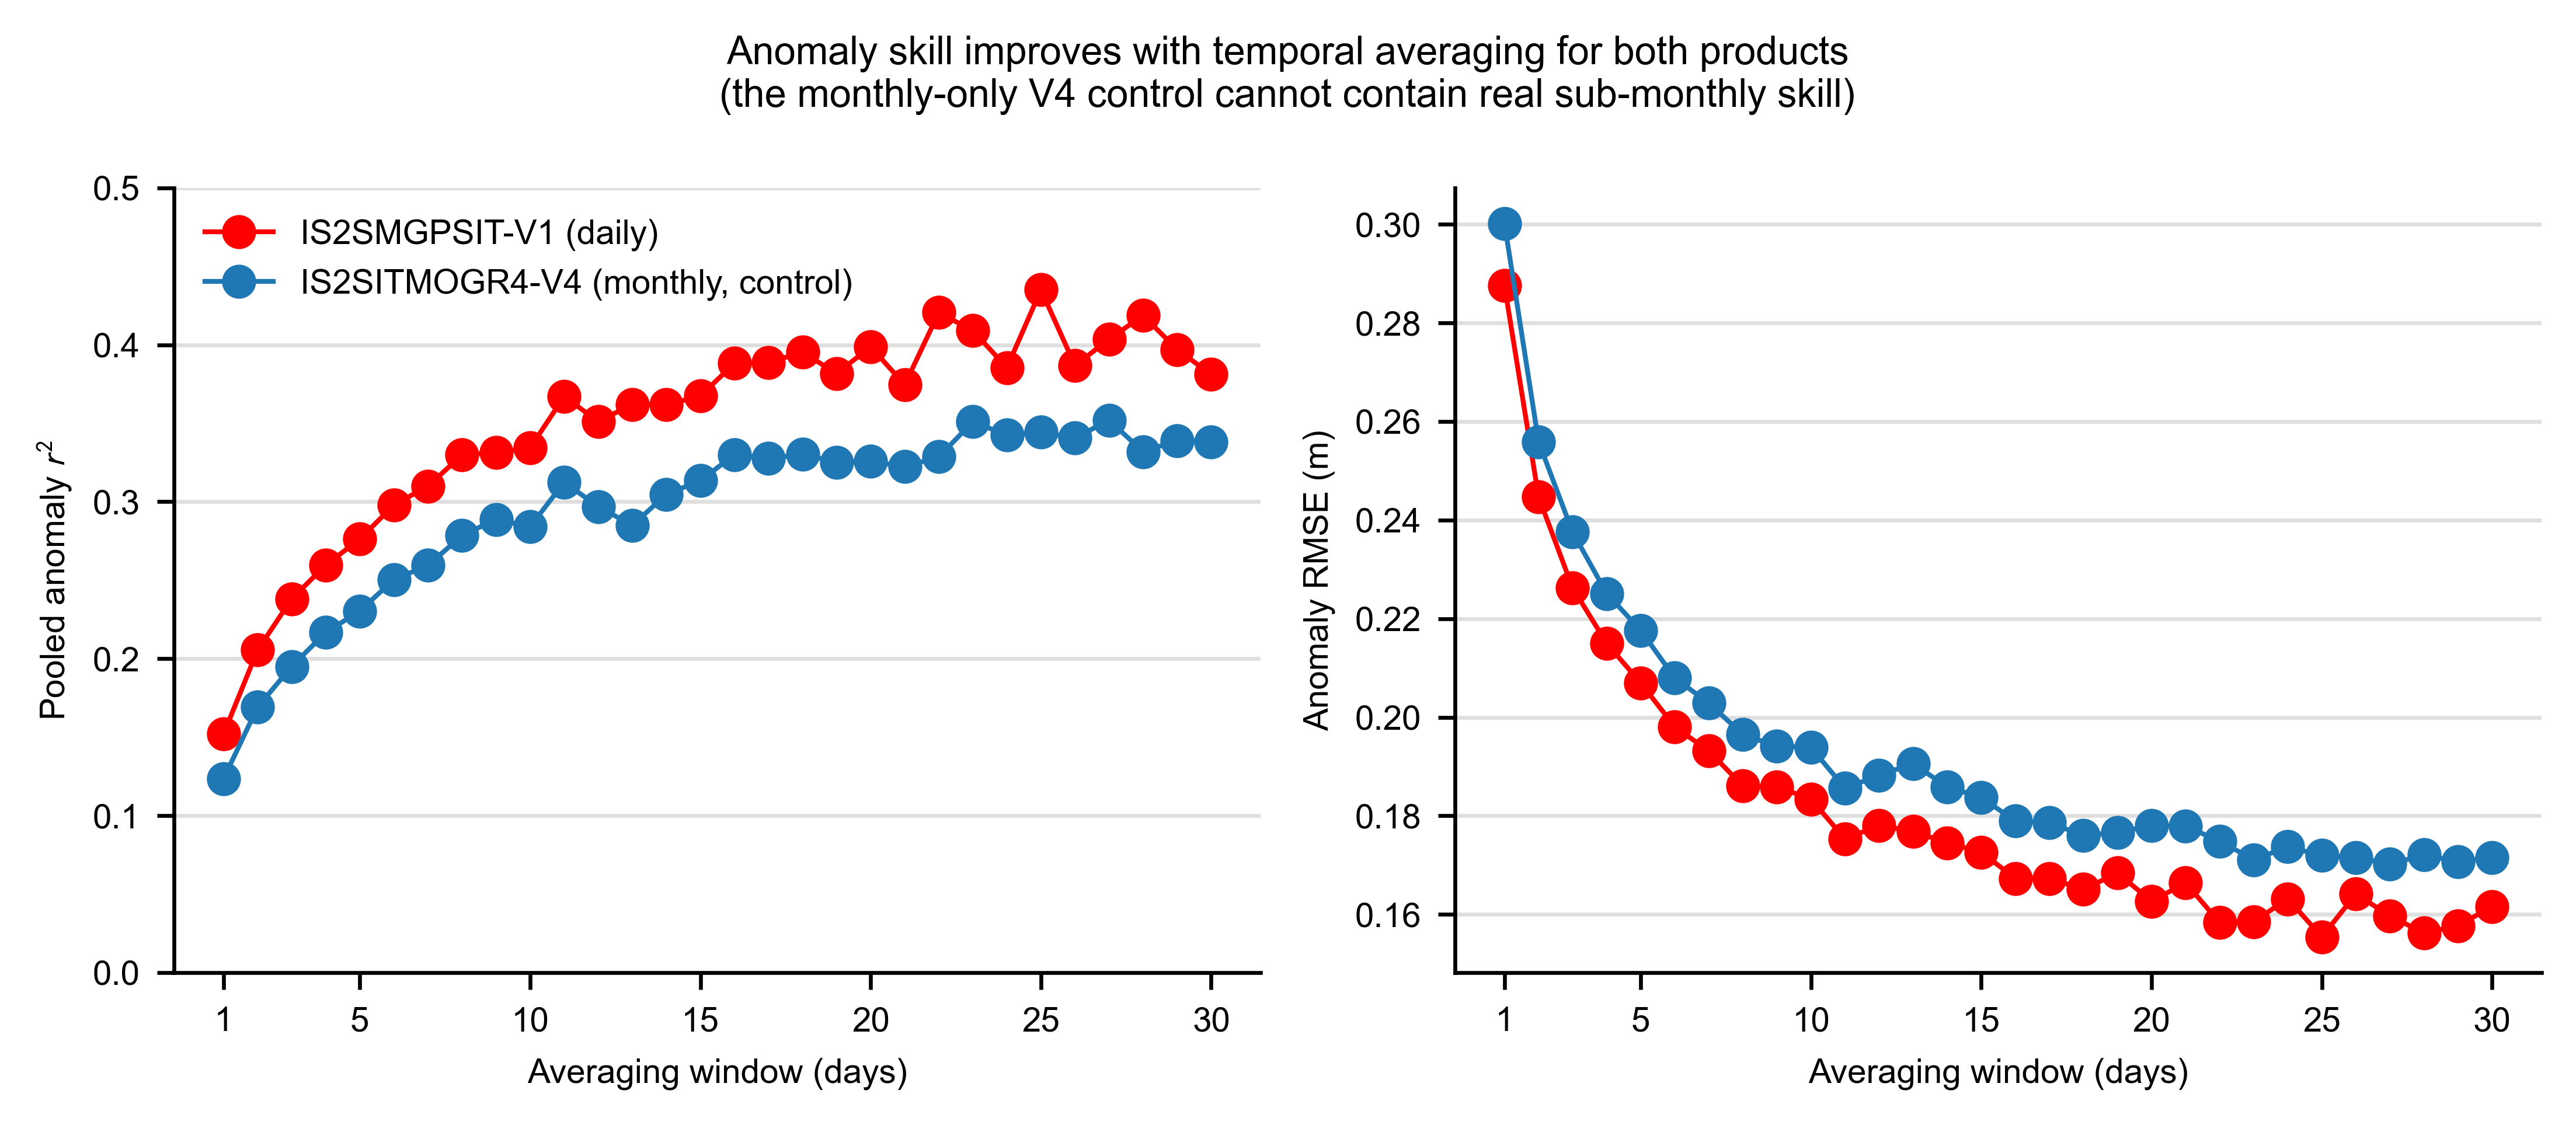

In [15]:
# Anomaly skill as a function of averaging window (noise-averaging test)
# Use a SINGLE anomaly definition (the daily day-of-year anomalies built above) and
# only change the averaging window, so the seasonal removal is identical throughout.
# Averaging the daily anomalies to W-day means isolates the effect of temporal
# smoothing alone.
windows = list(range(1, 31))
diag_products = {
    'fused_daily': 'IS2SMGPSIT-V1 (daily)',
    'v4_monthly': 'IS2SITMOGR4-V4 (monthly, control)',
}


def _win_mean(s, window):
    return s.resample(f'{window}D').mean()


stats_by_window = {p: {'r2': [], 'rmse': []} for p in diag_products}
n_by_window = []
for w in windows:
    n_used = 0
    for p in diag_products:
        frames = []
        for letter in ['a', 'b', 'd']:
            dfa = colloc_anom[letter]
            frames.append(pd.DataFrame({
                'u': _win_mean(dfa['uls_draft_anom'], w),
                'p': _win_mean(dfa[p + '_anom'], w),
            }))
        big = pd.concat(frames, ignore_index=True)
        m = np.isfinite(big['u']) & np.isfinite(big['p'])
        if m.sum() > 2:
            r2 = stats.pearsonr(big['u'][m], big['p'][m])[0] ** 2
            rmse = np.sqrt(np.nanmean((big['p'][m].values - big['u'][m].values) ** 2))
        else:
            r2 = rmse = np.nan
        stats_by_window[p]['r2'].append(r2)
        stats_by_window[p]['rmse'].append(rmse)
        if p == 'fused_daily':
            n_used = int(m.sum())
    n_by_window.append(n_used)

print('Anomaly skill vs averaging window (pooled A+B+D):')
print(f'{"window(d)":>9} {"N":>6} '
      f'{"V1 r^2":>8} {"V1 RMSE":>9} {"V4 r^2":>8} {"V4 RMSE":>9}')
for i, w in enumerate(windows):
    print(f'{w:>9} {n_by_window[i]:>6} '
          f'{stats_by_window["fused_daily"]["r2"][i]:>8.2f} '
          f'{stats_by_window["fused_daily"]["rmse"][i]:>9.2f} '
          f'{stats_by_window["v4_monthly"]["r2"][i]:>8.2f} '
          f'{stats_by_window["v4_monthly"]["rmse"][i]:>9.2f}')

fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.2))
colors = {'fused_daily': 'r', 'v4_monthly': 'C0'}
for key, ylab, ax in [('r2', 'Pooled anomaly $r^2$', axes[0]),
                      ('rmse', 'Anomaly RMSE (m)', axes[1])]:
    for p, lab in diag_products.items():
        ax.plot(windows, stats_by_window[p][key], '-o', color=colors[p], label=lab)
    ax.set_xlabel('Averaging window (days)')
    ax.set_ylabel(ylab)
    ax.set_xticks([1, 5, 10, 15, 20, 25, 30])
    ax.grid(axis='y', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axes[0].set_ylim(0, 0.5)
axes[0].legend(frameon=False, fontsize=7)
fig.suptitle('Anomaly skill improves with temporal averaging for both products\n'
             '(the monthly-only V4 control cannot contain real sub-monthly skill)',
             fontsize=8)
plt.tight_layout()
plt.savefig('../paper/figures/BGEP_anomaly_r2_vs_window.png', dpi=300)
plt.show()


## Scatter plots: IS2 ice draft vs BGEP draft (daily)

One panel per product (IS2SITMOGR4-V4 monthly, IS2SMGPSIT-V1 monthly, IS2SMGPSIT-V1 daily), coloured by mooring.

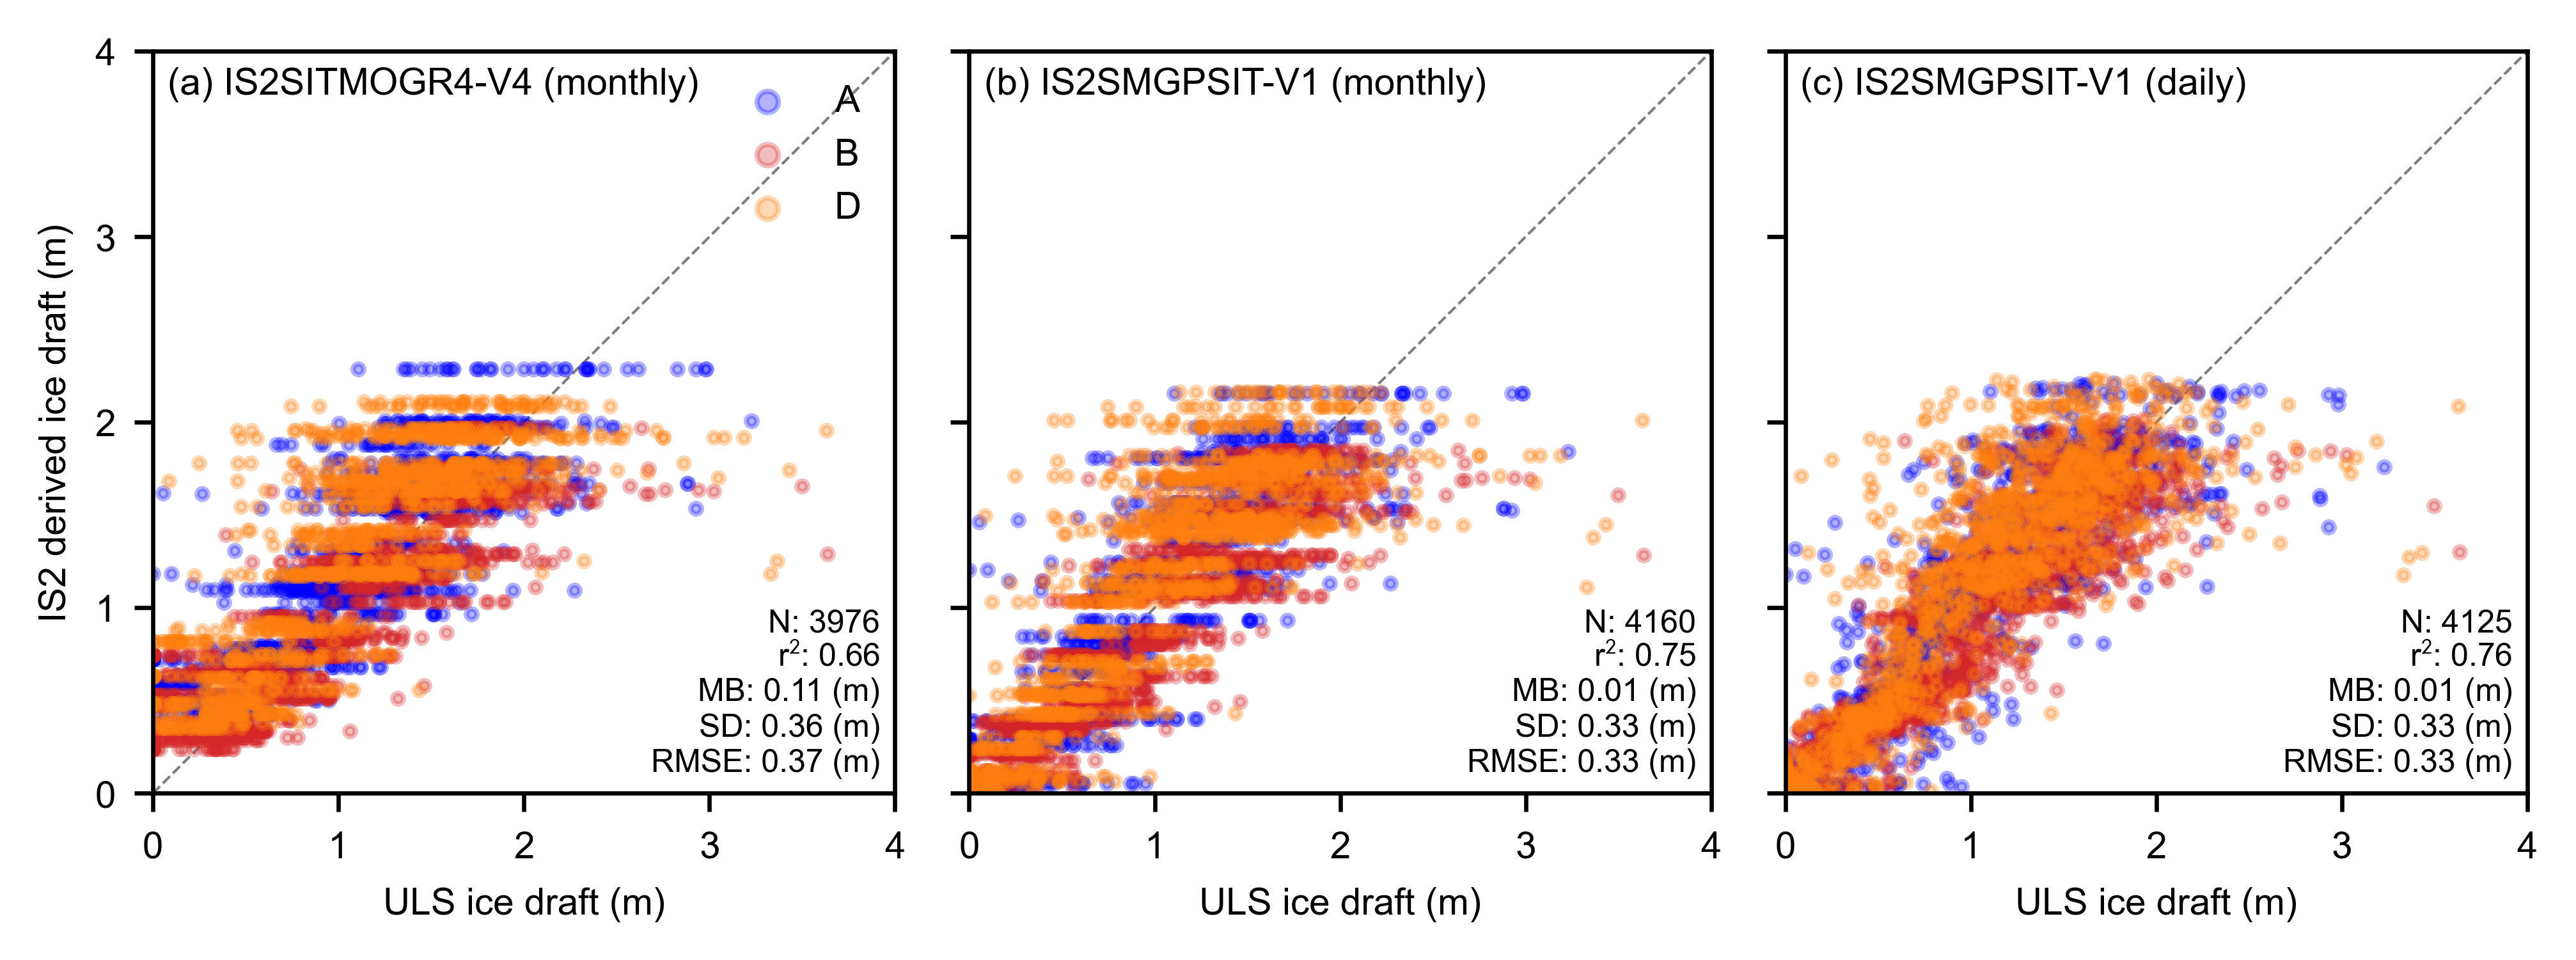

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(6.8, 3.0),
                         gridspec_kw={'wspace': 0.10})

panel_labels = ['(a)', '(b)', '(c)']
mooring_colors = {'a': 'b', 'b': 'tab:red', 'd': 'tab:orange'}

for i, (prod, label) in enumerate(zip(products, product_labels)):
    ax = axes[i]
    vr = validation_results[prod]

    for letter in ['a', 'b', 'd']:
        df = colloc[letter]
        mask = np.isfinite(df['uls_draft']) & np.isfinite(df[prod])
        ax.scatter(df['uls_draft'][mask], df[prod][mask],
                   color=mooring_colors[letter], alpha=0.3, s=4,
                   label=letter.upper())

    ax.annotate(
        f"N: {vr['n_all']}\n"
        f"r$^2$: {vr['r2_all']:.2f}\n"
        f"MB: {vr['mb_all']:.2f} (m)\n"
        f"SD: {vr['sd_all']:.2f} (m)\n"
        f"RMSE: {vr['rmse_all']:.2f} (m)",
        color='k', xy=(0.98, 0.02), xycoords='axes fraction',
        ha='right', va='bottom', fontsize=6,
    )

    ax.annotate(f'{panel_labels[i]} {label}', xy=(0.02, 0.98),
                xycoords='axes fraction', ha='left', va='top', fontsize=7)

    if i == 0:
        ax.legend(frameon=False, loc='upper right', markerscale=2)
        ax.set_ylabel('IS2 derived ice draft (m)')
    else:
        ax.set_yticklabels('')

    ax.set_xlabel('ULS ice draft (m)')
    ax.set_xlim([0, 4])
    ax.set_ylim([0, 4])
    ax.set_xticks([0, 1, 2, 3, 4])
    ax.set_yticks([0, 1, 2, 3, 4])
    ax.plot([0, 4], [0, 4], 'k--', linewidth=0.5, alpha=0.5, zorder=0)
    ax.set_aspect('equal')

plt.subplots_adjust(left=0.07, right=0.98, top=0.95, bottom=0.14)
plt.savefig('../paper/figures/BGEP_V4_vs_V1_daily_scatter.png', dpi=300)
plt.show()


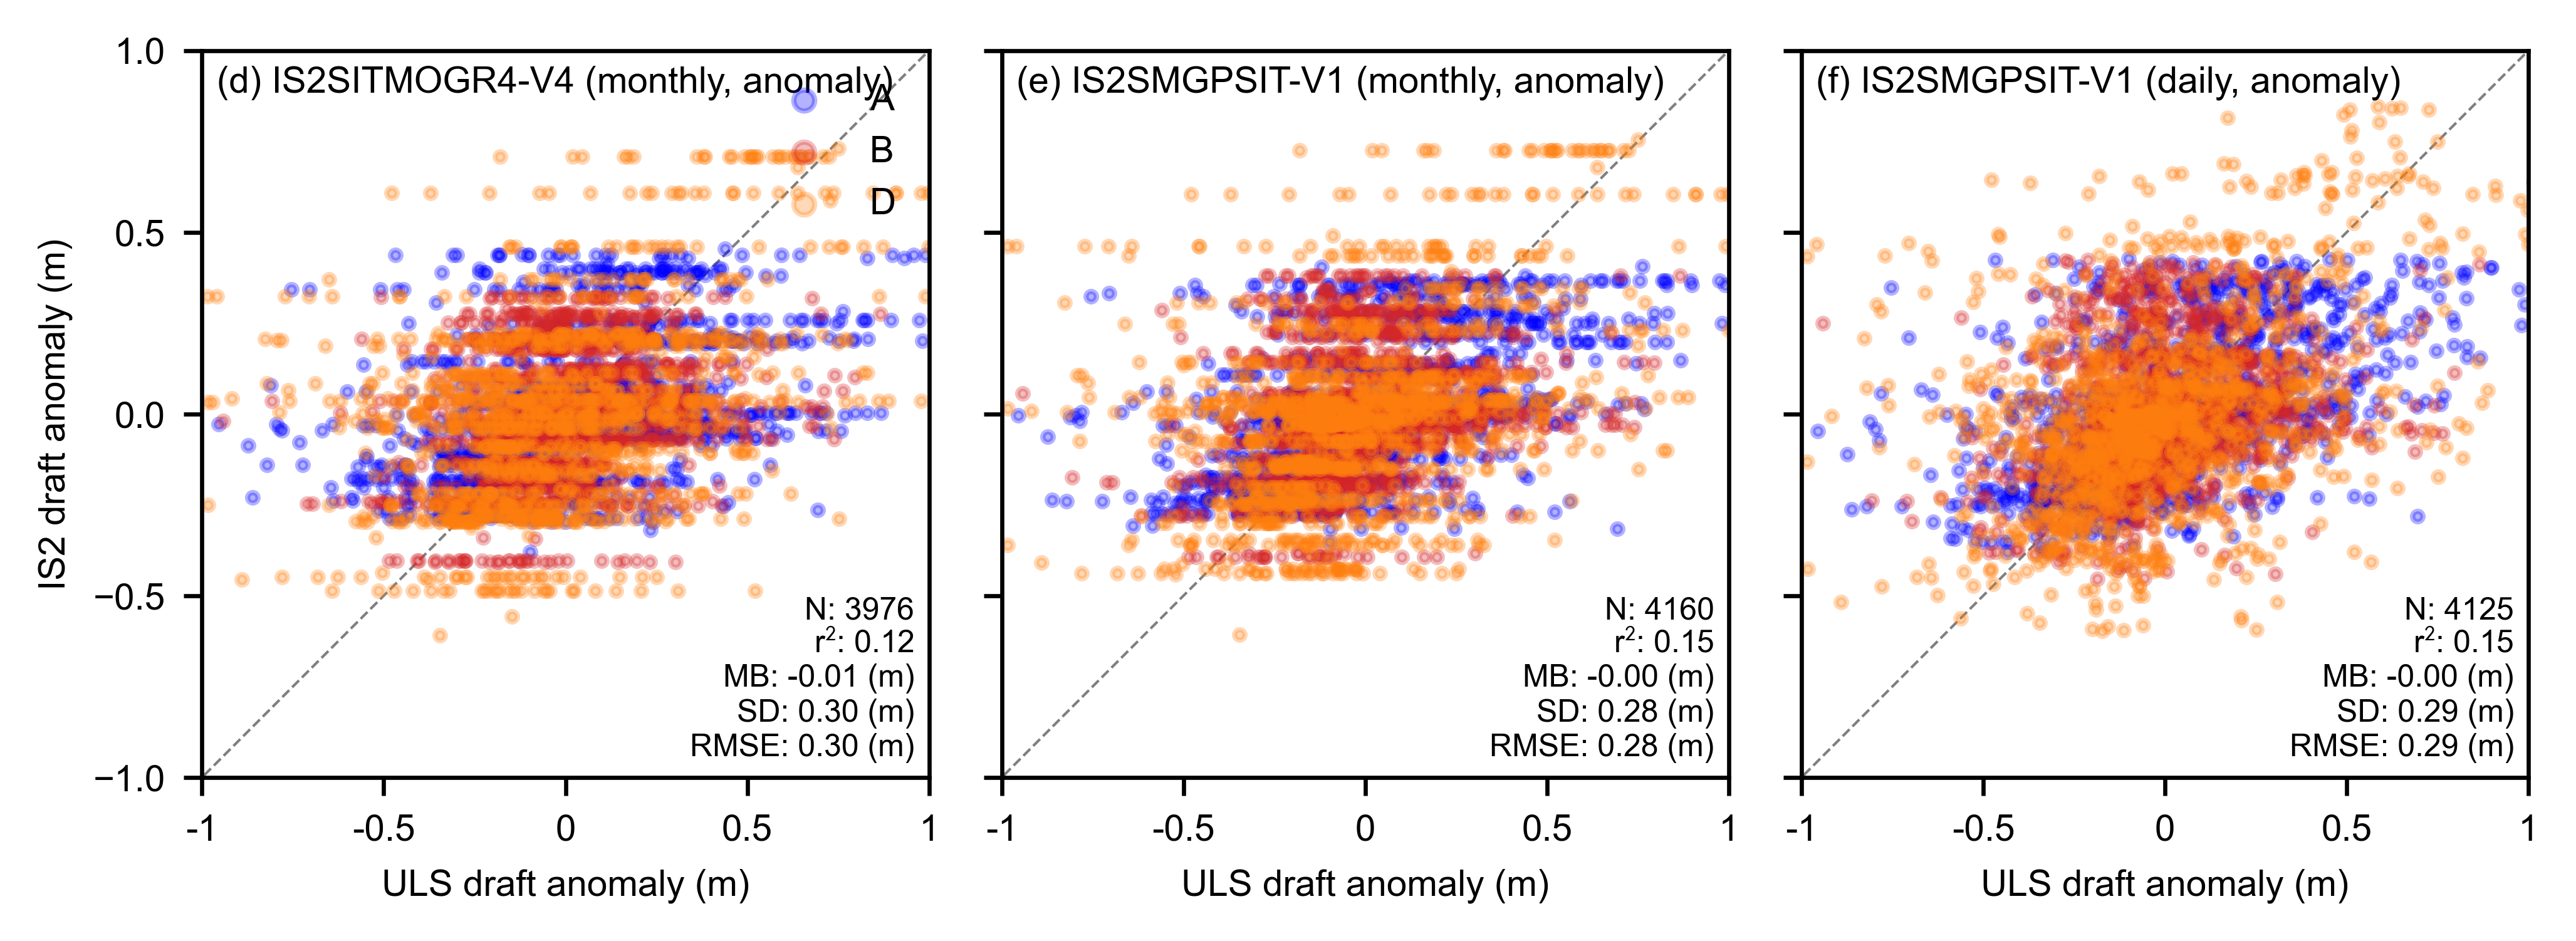

Correlation/fit statistics of draft anomalies (pooled A+B+D):
  IS2SITMOGR4-V4 (monthly, anomaly): N=3976, r^2=0.12, MB=-0.01 m, SD=0.30 m, RMSE=0.30 m
  IS2SMGPSIT-V1 (monthly, anomaly): N=4160, r^2=0.15, MB=-0.00 m, SD=0.28 m, RMSE=0.28 m
  IS2SMGPSIT-V1 (daily, anomaly): N=4125, r^2=0.15, MB=-0.00 m, SD=0.29 m, RMSE=0.29 m


In [17]:
# Scatter plots with seasonal cycle removed (anomalies)

anom_products = ['v4_monthly_anom', 'fused_monthly_anom', 'fused_daily_anom']
anom_labels = [
    'IS2SITMOGR4-V4 (monthly, anomaly)',
    'IS2SMGPSIT-V1 (monthly, anomaly)',
    'IS2SMGPSIT-V1 (daily, anomaly)',
]

validation_results_anom = {}

for prod, label in zip(anom_products, anom_labels):
    vr = {}
    for letter in ['a', 'b', 'd']:
        df = colloc_anom[letter]
        mask = np.isfinite(df['uls_draft_anom']) & np.isfinite(df[prod])
        if mask.sum() >= 2:
            res = stats.linregress(df[prod][mask], df['uls_draft_anom'][mask])
            vr[f'r2_{letter}'] = res.rvalue**2
            vr[f'mb_{letter}'] = np.nanmean(df[prod][mask].values - df['uls_draft_anom'][mask].values)
            vr[f'sd_{letter}'] = np.nanstd(df[prod][mask].values - df['uls_draft_anom'][mask].values)
            vr[f'rmse_{letter}'] = np.sqrt(np.nanmean((df[prod][mask].values - df['uls_draft_anom'][mask].values) ** 2))
            vr[f'n_{letter}'] = int(mask.sum())
        else:
            vr[f'r2_{letter}'] = vr[f'mb_{letter}'] = vr[f'sd_{letter}'] = vr[f'rmse_{letter}'] = np.nan
            vr[f'n_{letter}'] = 0

    all_is2 = np.concatenate([colloc_anom[l][prod].values for l in ['a', 'b', 'd']])
    all_uls = np.concatenate([colloc_anom[l]['uls_draft_anom'].values for l in ['a', 'b', 'd']])
    mask_all = np.isfinite(all_is2) & np.isfinite(all_uls)
    if mask_all.sum() >= 2:
        res = stats.linregress(all_is2[mask_all], all_uls[mask_all])
        vr['r2_all'] = res.rvalue**2
        vr['mb_all'] = np.nanmean(all_is2[mask_all] - all_uls[mask_all])
        vr['sd_all'] = np.nanstd(all_is2[mask_all] - all_uls[mask_all])
        vr['rmse_all'] = np.sqrt(np.nanmean((all_is2[mask_all] - all_uls[mask_all]) ** 2))
        vr['n_all'] = int(mask_all.sum())
    else:
        vr['r2_all'] = vr['mb_all'] = vr['sd_all'] = vr['rmse_all'] = np.nan
        vr['n_all'] = 0

    validation_results_anom[prod] = vr

fig, axes = plt.subplots(1, 3, figsize=(6.8, 2.7), gridspec_kw={'wspace': 0.10})
panel_labels = ['(d)', '(e)', '(f)']
mooring_colors = {'a': 'b', 'b': 'tab:red', 'd': 'tab:orange'}

for i, (prod, label) in enumerate(zip(anom_products, anom_labels)):
    ax = axes[i]
    vr = validation_results_anom[prod]

    for letter in ['a', 'b', 'd']:
        df = colloc_anom[letter]
        mask = np.isfinite(df['uls_draft_anom']) & np.isfinite(df[prod])
        ax.scatter(df['uls_draft_anom'][mask], df[prod][mask],
                   color=mooring_colors[letter], alpha=0.3, s=4, label=letter.upper())

    ax.annotate(
        f"N: {vr['n_all']}\n"
        f"r$^2$: {vr['r2_all']:.2f}\n"
        f"MB: {vr['mb_all']:.2f} (m)\n"
        f"SD: {vr['sd_all']:.2f} (m)\n"
        f"RMSE: {vr['rmse_all']:.2f} (m)",
        color='k', xy=(0.98, 0.02), xycoords='axes fraction',
        ha='right', va='bottom', fontsize=6,
    )

    ax.annotate(f"{panel_labels[i]} {label}", xy=(0.02, 0.98),
                xycoords='axes fraction', ha='left', va='top', fontsize=7)

    if i == 0:
        ax.legend(frameon=False, loc='upper right', markerscale=2)
        ax.set_ylabel('IS2 draft anomaly (m)')
    else:
        ax.set_yticklabels('')

    ax.set_xlabel('ULS draft anomaly (m)')
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_xticks([-1, -0.5, 0, 0.5, 1])
    ax.set_xticklabels(['-1', '-0.5', '0', '0.5', '1'])
    ax.set_yticks([-1, -0.5, 0, 0.5, 1])
    ax.plot([-2.5, 2.5], [-2.5, 2.5], 'k--', linewidth=0.5, alpha=0.5, zorder=0)
    ax.set_aspect('equal')

plt.subplots_adjust(left=0.07, right=0.98, top=0.99, bottom=0.18)
plt.savefig('../paper/figures/BGEP_V4_vs_V1_daily_scatter_subseasonal.png', dpi=300)
plt.show()

print('Correlation/fit statistics of draft anomalies (pooled A+B+D):')
for prod, label in zip(anom_products, anom_labels):
    vr = validation_results_anom[prod]
    print(f"  {label}: N={vr['n_all']}, r^2={vr['r2_all']:.2f}, MB={vr['mb_all']:.2f} m, SD={vr['sd_all']:.2f} m, RMSE={vr['rmse_all']:.2f} m")


## Weekly validation and averaging-window table

Weekly means use Monday–Sunday bins labelled by their Thursday midpoint and require at least four valid daily observations (same method as the former notebook 11d). IS2SITMOGR4-V4 remains a nearest-monthly control. Monthly rows are imported from notebook 11b so the calendar-month collocation is unchanged.

This cell writes:
- `../paper/tables/bgep_validation_by_window.csv`
- `../paper/tables/bgep_validation_by_window_rows.tex` (body rows for `tab:windows`)


In [18]:
# Consolidated daily/weekly/monthly validation table (paper Table tab:windows)
# Weekly means use Monday-Sunday bins labelled by their Thursday midpoint and
# require at least four valid daily observations, matching the former 11d method.
from pathlib import Path

nearest_monthly_tolerance = pd.Timedelta(days=20)


def daily_to_weekly(series, min_count=4):
    """Average a daily series to Monday-Sunday weeks labelled by Thursday."""
    s = pd.Series(series).copy()
    s.index = pd.to_datetime(s.index)
    s = s.sort_index().dropna()
    week_start = s.index.to_period('W-SUN').start_time
    weekly = s.groupby(week_start).mean()
    counts = s.groupby(week_start).count()
    weekly[counts < min_count] = np.nan
    weekly.index = pd.to_datetime(weekly.index) + pd.Timedelta(days=3)
    return weekly.sort_index()


def monthly_control_series(daily_v4):
    """One mid-month V4 value per calendar month for nearest-month matching."""
    s = pd.Series(daily_v4).dropna().copy()
    s.index = pd.to_datetime(s.index)
    by_month = s.groupby(s.index.to_period('M')).first()
    by_month.index = by_month.index.to_timestamp(how='start') + pd.Timedelta(days=14)
    return by_month.sort_index()


def pooled_validation(colloc_dict, products, ref_col='uls_draft'):
    """Return pooled A+B+D validation statistics for each product."""
    results = {}
    for product in products:
        product_values = np.concatenate([
            colloc_dict[letter][product].values for letter in ['a', 'b', 'd']
        ])
        reference_values = np.concatenate([
            colloc_dict[letter][ref_col].values for letter in ['a', 'b', 'd']
        ])
        valid = np.isfinite(product_values) & np.isfinite(reference_values)
        if valid.sum() >= 2:
            residual = product_values[valid] - reference_values[valid]
            regression = stats.linregress(product_values[valid], reference_values[valid])
            results[product] = {
                'n_all': int(valid.sum()),
                'r2_all': regression.rvalue**2,
                'mb_all': float(np.mean(residual)),
                'sd_all': float(np.std(residual)),
                'rmse_all': float(np.sqrt(np.mean(residual**2))),
            }
        else:
            results[product] = {
                'n_all': int(valid.sum()), 'r2_all': np.nan, 'mb_all': np.nan,
                'sd_all': np.nan, 'rmse_all': np.nan,
            }
    return results


weekly_colloc = {}
for letter in ['a', 'b', 'd']:
    daily = colloc[letter]
    weekly = pd.DataFrame({'uls_draft': daily_to_weekly(daily['uls_draft'])})
    weekly['fused_weekly'] = daily_to_weekly(daily['fused_daily']).reindex(weekly.index)
    v4_pts = monthly_control_series(daily['v4_monthly'])
    weekly['v4_monthly'] = pd.merge_asof(
        weekly[['uls_draft']].sort_index(),
        v4_pts.rename('v').to_frame(),
        left_index=True, right_index=True,
        tolerance=nearest_monthly_tolerance, direction='nearest',
    )['v']
    weekly_colloc[letter] = weekly
    print(
        f'Mooring {letter.upper()}: {len(weekly)} weekly ULS means, '
        f'V4 valid={weekly["v4_monthly"].notna().sum()}, '
        f'fused-weekly valid={weekly["fused_weekly"].notna().sum()}'
    )

weekly_products = ['v4_monthly', 'fused_weekly']
weekly_labels = {
    'v4_monthly': 'IS2SITMOGR4-V4 (nearest monthly)',
    'fused_weekly': 'IS2SMGPSIT-V1 (weekly)',
}
weekly_validation = pooled_validation(weekly_colloc, weekly_products)

print('\nWeekly full-signal validation (pooled A+B+D):')
for product in weekly_products:
    vr = weekly_validation[product]
    print(
        f"  {weekly_labels[product]}: N={vr['n_all']}, "
        f"r^2={vr['r2_all']:.2f}, RMSE={vr['rmse_all']:.2f} m"
    )

weekly_colloc_anom = {}
for letter in ['a', 'b', 'd']:
    weekly = weekly_colloc[letter].copy()
    week_number = weekly.index.isocalendar().week.astype(int).to_numpy()
    for column in ['uls_draft'] + weekly_products:
        climatology = weekly.groupby(week_number)[column].mean()
        weekly[column + '_anom'] = (
            weekly[column].values - climatology.reindex(week_number).values
        )
    weekly_colloc_anom[letter] = weekly

weekly_validation_anom = pooled_validation(
    weekly_colloc_anom,
    [product + '_anom' for product in weekly_products],
    ref_col='uls_draft_anom',
)

print('\nWeekly anomaly validation (pooled A+B+D):')
for product in weekly_products:
    vr = weekly_validation_anom[product + '_anom']
    print(
        f"  {weekly_labels[product]}: N={vr['n_all']}, "
        f"r^2={vr['r2_all']:.2f}, RMSE={vr['rmse_all']:.2f} m"
    )


def validation_row(window, product_label, full, anomaly):
    return {
        'window': window,
        'product': product_label,
        'N': full['n_all'],
        'full_r2': full['r2_all'],
        'full_rmse_m': full['rmse_all'],
        'anomaly_r2': anomaly['r2_all'],
        'anomaly_rmse_m': anomaly['rmse_all'],
    }


window_rows = [
    validation_row(
        'Daily', 'IS2SITMOGR4-V4 (nearest month)',
        validation_results['v4_monthly'],
        validation_results_anom['v4_monthly_anom'],
    ),
    validation_row(
        'Daily', 'IS2SMGPSIT-V1 (daily)',
        validation_results['fused_daily'],
        validation_results_anom['fused_daily_anom'],
    ),
    validation_row(
        'Weekly', 'IS2SITMOGR4-V4 (nearest month)',
        weekly_validation['v4_monthly'],
        weekly_validation_anom['v4_monthly_anom'],
    ),
    validation_row(
        'Weekly', 'IS2SMGPSIT-V1 (weekly)',
        weekly_validation['fused_weekly'],
        weekly_validation_anom['fused_weekly_anom'],
    ),
]

monthly_stats_path = Path('./data/bgep_validation/monthly_pooled_stats.csv')
if not monthly_stats_path.exists():
    raise FileNotFoundError(
        f'{monthly_stats_path} is missing. Run notebook 11b before 11c so the '
        'formal monthly validation rows can be included.'
    )

monthly_validation_table = pd.read_csv(monthly_stats_path)
validation_by_window = pd.concat(
    [pd.DataFrame(window_rows), monthly_validation_table], ignore_index=True,
)
validation_by_window['N'] = validation_by_window['N'].astype(int)

# Also keep a local copy next to the 11b monthly export
local_dir = Path('./data/bgep_validation')
local_dir.mkdir(parents=True, exist_ok=True)
local_csv = local_dir / 'bgep_validation_by_window.csv'
validation_by_window.to_csv(local_csv, index=False)

output_dir = Path('../paper/tables')
output_dir.mkdir(parents=True, exist_ok=True)
csv_path = output_dir / 'bgep_validation_by_window.csv'
tex_path = output_dir / 'bgep_validation_by_window_rows.tex'
validation_by_window.to_csv(csv_path, index=False)

latex_rows = []
for row in validation_by_window.itertuples(index=False):
    latex_rows.append(
        f'{row.window} & {row.product} & {row.N:d} & '
        f'{row.full_r2:.2f} & {row.full_rmse_m:.2f} & '
        f'{row.anomaly_r2:.2f} & {row.anomaly_rmse_m:.2f} \\\\'
    )
tex_path.write_text('\n'.join(latex_rows) + '\n\\bottomrule\n')

print(f'\nSaved complete validation table to {csv_path}')
print(f'Saved local copy to {local_csv}')
print(f'Saved LaTeX rows to {tex_path}')
display(validation_by_window.round(3))


Mooring A: 311 weekly ULS means, V4 valid=234, fused-weekly valid=197
Mooring B: 294 weekly ULS means, V4 valid=247, fused-weekly valid=199
Mooring D: 313 weekly ULS means, V4 valid=229, fused-weekly valid=201

Weekly full-signal validation (pooled A+B+D):
  IS2SITMOGR4-V4 (nearest monthly): N=703, r^2=0.80, RMSE=0.29 m
  IS2SMGPSIT-V1 (weekly): N=596, r^2=0.88, RMSE=0.23 m

Weekly anomaly validation (pooled A+B+D):
  IS2SITMOGR4-V4 (nearest monthly): N=703, r^2=0.23, RMSE=0.21 m
  IS2SMGPSIT-V1 (weekly): N=596, r^2=0.35, RMSE=0.19 m

Saved complete validation table to ../paper/tables/bgep_validation_by_window.csv
Saved local copy to data/bgep_validation/bgep_validation_by_window.csv
Saved LaTeX rows to ../paper/tables/bgep_validation_by_window_rows.tex


,window,product,N,full_r2,full_rmse_m,anomaly_r2,anomaly_rmse_m
0,Daily,IS2SITMOGR4-V4 (nearest month),3976,0.664,0.372,0.124,0.300
1,Daily,IS2SMGPSIT-V1 (daily),4125,0.757,0.327,0.152,0.288
2,Weekly,IS2SITMOGR4-V4 (nearest month),703,0.796,0.291,0.235,0.210
3,Weekly,IS2SMGPSIT-V1 (weekly),596,0.876,0.226,0.350,0.191
4,Monthly,IS2SITMOGR4-V4,130,0.834,0.245,0.363,0.173
5,Monthly,IS2SMGPSIT-V1 (monthly),140,0.913,0.189,0.419,0.157


## Hexbin plots: anomaly density (pooled A+B+D)

Hexbin plots reduce overplotting and highlight where monthly products appear streaky or less consistent compared with the daily fused product.

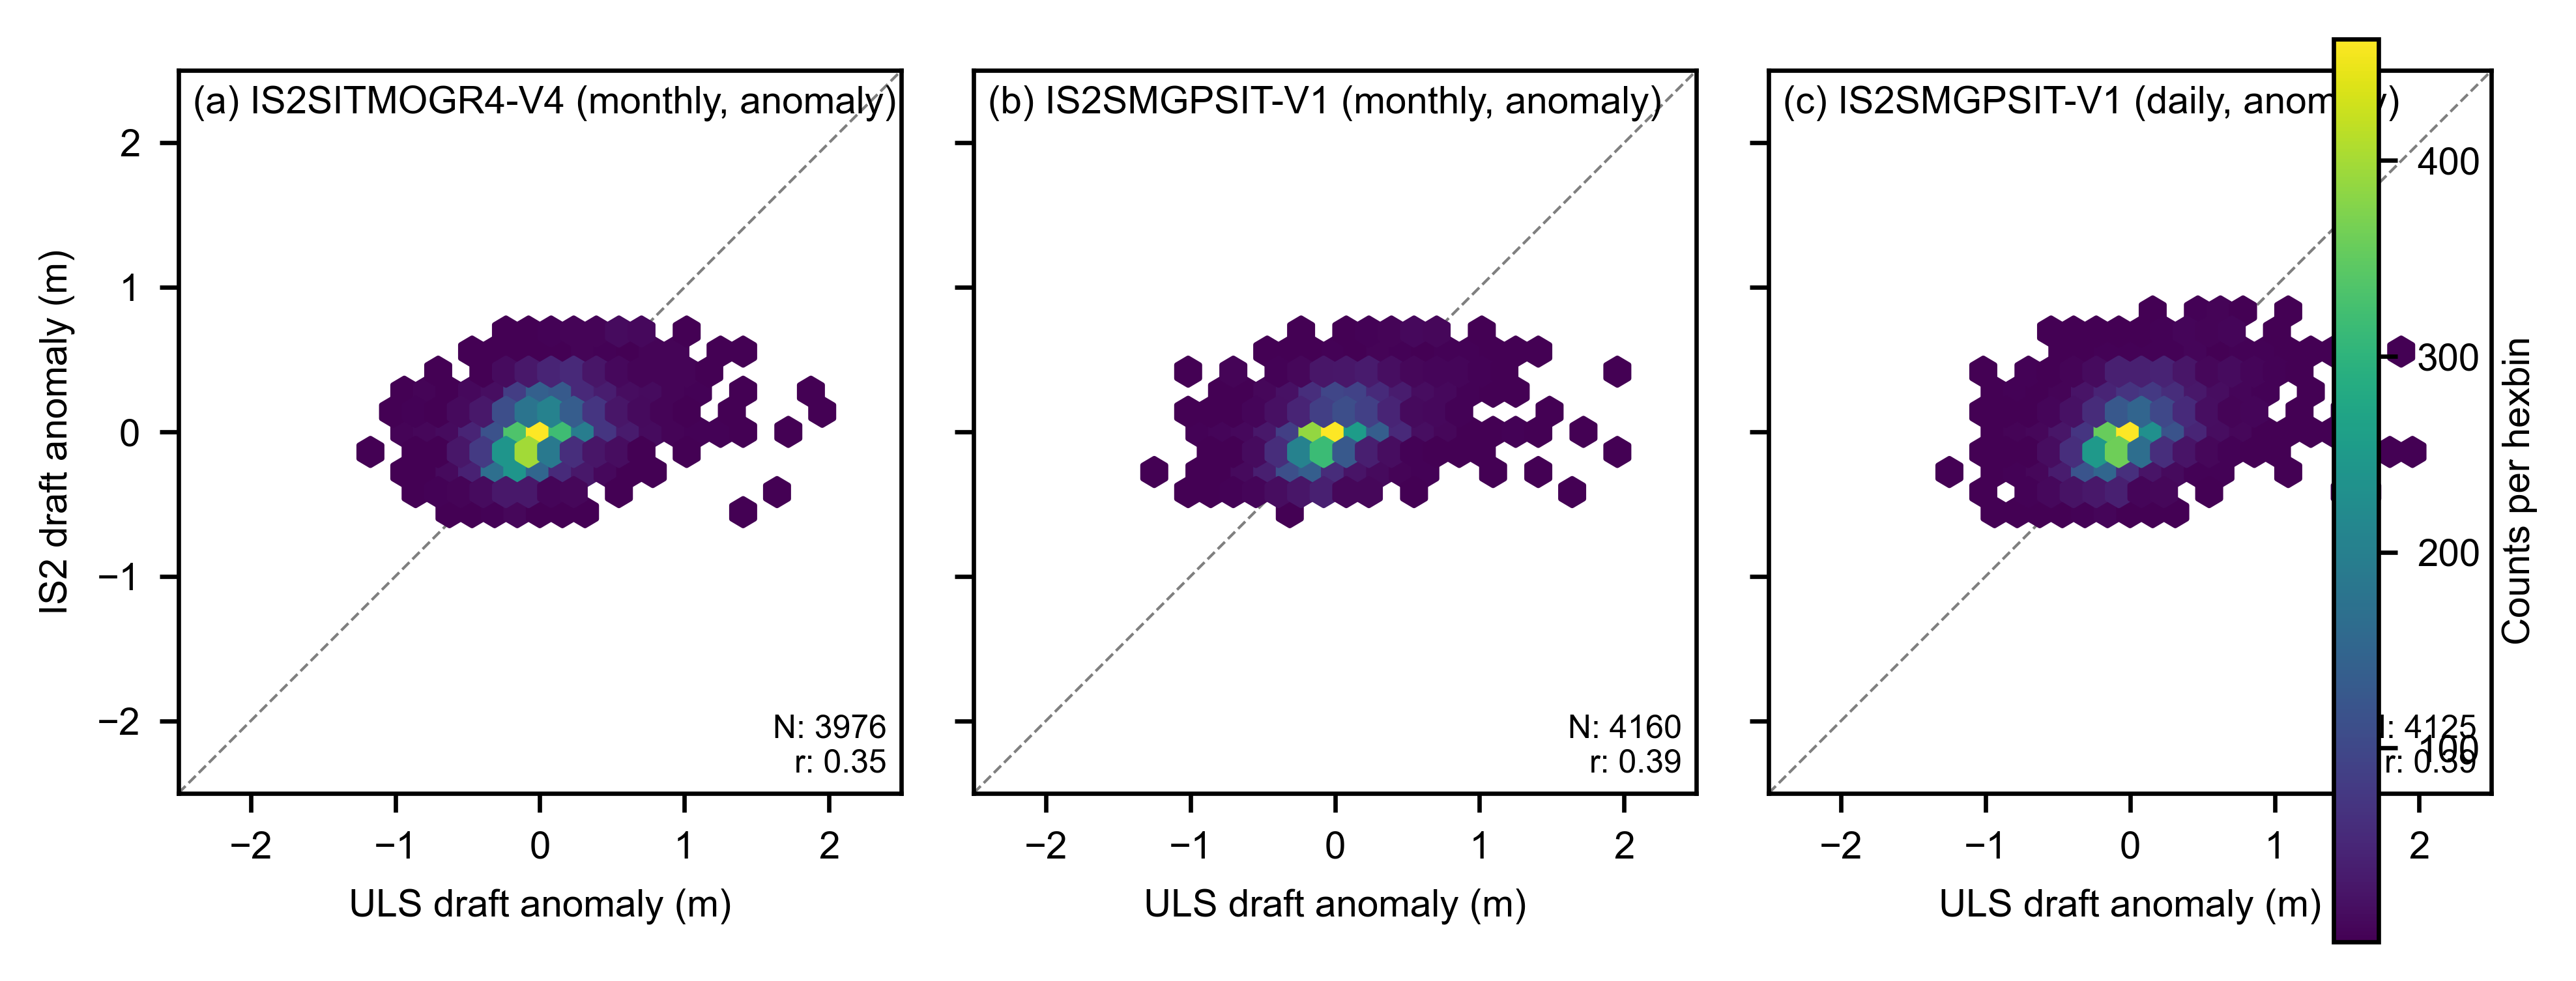

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(6.8, 3.0), gridspec_kw={'wspace': 0.10})
panel_labels = ['(a)', '(b)', '(c)']

for i, (prod, label) in enumerate(zip(anom_products, anom_labels)):
    ax = axes[i]

    all_uls = np.concatenate([colloc_anom[l]['uls_draft_anom'].values for l in ['a', 'b', 'd']])
    all_is2 = np.concatenate([colloc_anom[l][prod].values for l in ['a', 'b', 'd']])
    mask = np.isfinite(all_uls) & np.isfinite(all_is2)

    hb = ax.hexbin(
        all_uls[mask], all_is2[mask],
        gridsize=32, mincnt=1, cmap='viridis',
        extent=[-2.5, 2.5, -2.5, 2.5]
    )

    if mask.sum() >= 2:
        r = np.corrcoef(all_uls[mask], all_is2[mask])[0, 1]
        ax.annotate(
            f"N: {mask.sum()}\n"
            f"r: {r:.2f}",
            color='k', xy=(0.98, 0.02), xycoords='axes fraction',
            ha='right', va='bottom', fontsize=6,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.6),
        )

    ax.annotate(f"{panel_labels[i]} {label}", xy=(0.02, 0.98),
                xycoords='axes fraction', ha='left', va='top', fontsize=7)

    if i == 0:
        ax.set_ylabel('IS2 draft anomaly (m)')
    else:
        ax.set_yticklabels('')

    ax.set_xlabel('ULS draft anomaly (m)')
    ax.set_xlim([-2.5, 2.5])
    ax.set_ylim([-2.5, 2.5])
    ax.plot([-2.5, 2.5], [-2.5, 2.5], 'k--', linewidth=0.5, alpha=0.5, zorder=0)
    ax.set_aspect('equal')

cbar = fig.colorbar(hb, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
cbar.set_label('Counts per hexbin')

plt.subplots_adjust(left=0.07, right=0.94, top=0.95, bottom=0.14)
plt.savefig('./figs/BGEP_V4_fused_daily_scatter_subseasonal_hexbin.png', dpi=300)
plt.show()
